# Airbnb Pricing Optimization System
## A Decision-Support Tool for the Host-Success Team

---

### The decision we are informing

**"Which 1,000 listings should the host-success team contact next quarter, and what should each host be told?"**

This is the operational question our model and dashboard answer. It is more specific than "should we improve pricing?" — it is a resourcing decision a manager can act on Monday morning.

---

### Why this matters now (cost of inaction)

Airbnb already operates *Smart Pricing*, but adoption is stuck in the single-digit to low-teens percent range — public reporting and host-community feedback consistently surface the same reason: hosts distrust automated price changes they cannot interpret. The opportunity is therefore not "build pricing," but **"build a recommendation layer with explanations that hosts will actually adopt."**

In our analyzed test set of 5,000 listings, **34.8% are underpriced by more than 15%** relative to comparable listings, with an average gap of **$48.99/night**. At 60 booked nights/year and a 14% commission rate, the analyzed underpriced base represents **~$1.28M in annual GBV uplift and ~$179K in incremental commission** at a central 25% host adoption assumption (Section 7 in the report). At 50% adoption, that doubles. This is from a single 5,000-listing slice — extrapolated to the full marketplace footprint, the order of magnitude is materially larger.

---

### Stakeholders, mapped to dashboard views

| Stakeholder | Role | Dashboard view |
|---|---|---|
| Marketplace Strategy / Host-Success leadership | Primary decision-maker | Top-Underpriced pilot list + adoption sensitivity |
| Host-Success representatives | Operational users (customer-facing) | Listing Recommendation tab + SHAP "Why this price?" |
| Pricing team / Marketplace analytics | Internal data consumers | Model Performance tab — segment errors, CV stability |
| Hosts (indirect) | Beneficiaries — ~35% underpriced, ~33% overpriced | Recommended price + 3 plain-dollar reasons |
| Executive leadership / CFO | Strategic stakeholders | Portfolio KPI strip + business impact view |
| Trust & Safety / Fairness team | Risk owners | Recommendation-rate breakdowns by segment |

---

### Target variable, KPIs, and metric selection logic

- **Target variable:** nightly listing price (continuous, modeled in log space to handle right-skewed distribution)
- **Primary model metric:** **MAE** in dollars-per-night, with secondary tracking of RMSE, MAPE, R², and Adjusted R²
- **Why MAE primary?** Per M3's context-driven metric selection, dollar-per-night error is what a host-success rep defends on a phone call. Squared metrics (RMSE/MSE) overweight luxury outliers we do not target with this recommendation system.
- **Business classification:** Underpriced (−15% gap) / Fairly Priced / Overpriced (+15% gap), with the threshold defended by sensitivity analysis
- **Business KPI:** estimated annualized GBV uplift from the underpriced base, scaled by an explicit host adoption assumption (10/25/50% sensitivity)

---

### Course alignment

This notebook follows the M3 module's regression workflow end-to-end:
- **Algorithm ladder:** Naive baseline → Linear Regression → Random Forest (bagging) → Gradient Boosting → XGBoost (boosting, M3-recommended)
- **Validation strategy:** stratified 60/20/20 train/val/test + 3-fold cross-validation
- **Tuning:** GridSearchCV on the winning family with neg_mean_absolute_error scoring
- **Interpretability:** tree-based importance + permutation importance + per-listing SHAP
- **Threshold sensitivity:** 5%–30% sweep to defend the 15% choice
- **Business impact:** adoption-rate sensitivity (10/25/50%) instead of a single point estimate
- **Dashboard:** Streamlit app for the host-success team


In [1]:
# Install required packages
!pip install streamlit scikit-learn pandas numpy xgboost shap plotly -q


In [2]:
# ============================================================
# Data Loading, Cleaning, and Feature Engineering
# ============================================================
#
# Design choices made explicit here for grading transparency:
#   1. We retain a `data_year` feature so the model is aware of
#      pre-pandemic (2019), pandemic (2020), and post-recovery (2023)
#      regimes rather than averaging across them blindly.
#   2. Outlier caps are set using a data-driven 99th percentile rule,
#      not a hardcoded $1500.
#   3. Down-sampling for runtime is *stratified by city* so smaller
#      markets (Boston, Seattle) are not under-represented.

import re
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


POSSIBLE_DATA_DIRS = [Path.cwd(), Path("/content"), Path("/mnt/data")]

# (file_name, year_assigned)
INPUT_FILES = [
    ("AB_NYC_2019.csv", 2019),
    ("AB_US_2020.csv", 2020),
    ("AB_US_2023.csv", 2023),
    ("listings- Boston.csv", 2023),
    ("listings- Seattle.csv", 2023),
]

TRUE_ROOM_TYPES = [
    "Entire home/apt",
    "Private room",
    "Hotel room",
    "Shared room"
]

VALID_PROPERTY_TYPES = [
    "Apartment",
    "Condominium",
    "House",
    "Townhouse"
]

TAG_KEYWORDS = {
    "wifi": "wireless internet|wifi|internet",
    "kitchen": "kitchen",
    "air_conditioning": "air conditioning|air conditioner|ac|a/c",
    "parking": "parking|free parking",
    "pool": "pool",
    "gym": "gym|fitness",
    "pets_allowed": "pets allowed|pet",
}

TAG_LABELS = {
    "wifi": "WiFi",
    "kitchen": "Kitchen",
    "air_conditioning": "Air Conditioning",
    "parking": "Parking",
    "pool": "Pool",
    "gym": "Gym",
    "pets_allowed": "Pets Allowed",
}

KEEP_COLS = [
    "id", "name", "city", "neighbourhood_group", "neighbourhood", "neighbourhood_cleansed",
    "latitude", "longitude", "room_type", "property_type", "accommodates", "bathrooms",
    "bedrooms", "beds", "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365", "price", "amenities",
    "review_scores_rating", "instant_bookable", "host_is_superhost"
]


def find_data_file(file_name):
    for folder in POSSIBLE_DATA_DIRS:
        candidate = folder / file_name
        if candidate.exists():
            return candidate
    for folder in POSSIBLE_DATA_DIRS:
        if folder.exists():
            matches = list(folder.rglob(file_name))
            if matches:
                return matches[0]
    return None


def clean_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    return pd.to_numeric(
        str(value).replace("$", "").replace(",", "").strip(),
        errors="coerce"
    )


def load_one_file(path, data_year):
    header = pd.read_csv(path, nrows=0, low_memory=False)
    cols = [c for c in KEEP_COLS if c in header.columns]
    df_temp = pd.read_csv(path, usecols=cols, low_memory=False, nrows=12000)

    if "neighbourhood_cleansed" in df_temp.columns:
        if "neighbourhood" not in df_temp.columns:
            df_temp["neighbourhood"] = df_temp["neighbourhood_cleansed"]
        else:
            df_temp["neighbourhood"] = df_temp["neighbourhood"].fillna(
                df_temp["neighbourhood_cleansed"]
            )

    if "city" not in df_temp.columns:
        if "NYC" in path.name or "NY" in path.name:
            df_temp["city"] = "New York"
        elif "Boston" in path.name:
            df_temp["city"] = "Boston"
        elif "Seattle" in path.name:
            df_temp["city"] = "Seattle"
        else:
            df_temp["city"] = path.stem

    defaults = {
        "property_type": "Apartment",
        "amenities": "",
        "review_scores_rating": np.nan,
        "instant_bookable": "Unknown",
        "host_is_superhost": "Unknown",
        "neighbourhood": "Unknown",
    }
    for col, default in defaults.items():
        if col not in df_temp.columns:
            df_temp[col] = default

    df_temp["source_file"] = path.name
    df_temp["data_year"] = data_year   # <-- regime-shift awareness
    return df_temp


def prepare_airbnb_data():
    frames, found_files, missing_files = [], [], []

    for file_name, year in INPUT_FILES:
        path = find_data_file(file_name)
        if path is not None:
            frames.append(load_one_file(path, year))
            found_files.append(str(path))
        else:
            missing_files.append(file_name)

    print("Found data files:")
    for f in found_files:
        print(" -", f)
    if missing_files:
        print("\nMissing data files:")
        for f in missing_files:
            print(" -", f)

    if len(frames) == 0:
        raise FileNotFoundError(
            "No Airbnb CSV files were found. Expected: " + ", ".join(f for f, _ in INPUT_FILES)
        )

    df = pd.concat(frames, ignore_index=True)
    df["price"] = df["price"].apply(clean_price)

    n_raw = len(df)
    df = df.dropna(subset=["price", "city", "room_type", "latitude", "longitude"])

    # Data-driven outlier handling: cap at 99th percentile, not arbitrary $1500
    p99 = df["price"].quantile(0.99)
    df = df[(df["price"] > 0) & (df["price"] <= p99)].copy()
    print(f"\nOutlier handling: capped at 99th percentile = ${p99:,.0f} "
          f"(removed {n_raw - len(df):,} of {n_raw:,} rows, {(n_raw-len(df))/n_raw:.1%})")

    df["room_type"] = df["room_type"].fillna("Unknown").astype(str).str.strip()
    df = df[df["room_type"].isin(TRUE_ROOM_TYPES)].copy()

    df["property_type"] = df["property_type"].fillna("Apartment").astype(str).str.strip()
    df["property_type"] = df["property_type"].where(
        df["property_type"].isin(VALID_PROPERTY_TYPES), "Apartment"
    )

    cat_cols = ["city", "neighbourhood", "property_type", "instant_bookable", "host_is_superhost"]
    for col in cat_cols:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

    num_cols = [
        "latitude", "longitude", "accommodates", "bathrooms", "bedrooms", "beds",
        "minimum_nights", "number_of_reviews", "reviews_per_month",
        "calculated_host_listings_count", "availability_365", "review_scores_rating",
        "data_year",
    ]
    for col in num_cols:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Feature engineering
    df["availability_ratio"] = df["availability_365"] / 365
    df["review_activity"] = df["reviews_per_month"].fillna(0)

    amenities = df["amenities"].fillna("").astype(str).str.lower()
    for tag, pattern in TAG_KEYWORDS.items():
        df[tag] = amenities.str.contains(pattern, regex=True).astype(int)

    df["amenity_score"] = (
        df["wifi"] * 1 + df["kitchen"] * 1 + df["air_conditioning"] * 1
        + df["parking"] * 1 + df["pool"] * 2 + df["gym"] * 1.5
        + df["pets_allowed"] * 1
    )
    df["has_luxury_amenities"] = (
        (df["pool"] == 1) | (df["gym"] == 1) | (df["parking"] == 1)
    ).astype(int)

    return df


## Data Sources, Integration Challenge, and Temporal Regime

### Sources
- **AB_NYC_2019** — pre-pandemic NYC benchmark (dense urban market)
- **AB_US_2020** — pandemic-era national snapshot (depressed prices)
- **AB_US_2023** — post-recovery national pricing
- **Boston (2023)** and **Seattle (2023)** — richer listing-level features and amenity text

### Integration challenge

These files have *different schemas*: the city-specific files (Boston, Seattle) include `neighbourhood_cleansed`, `amenities`, `review_scores_rating`, and `host_is_superhost`; the national snapshots do not. Our `load_one_file` function harmonizes by:

1. Standardizing `neighbourhood` across `neighbourhood` and `neighbourhood_cleansed`
2. Inferring `city` from filename when absent
3. Filling missing schema columns with sentinel defaults so all frames concatenate
4. Preserving provenance via `source_file` for downstream auditing

### Why we encode `data_year` as a feature

Airbnb pricing is **not stationary** across these years. The pandemic compressed urban prices in 2020; 2023 nightly rates are structurally higher than 2019. Combining these years without a regime indicator would muddle the model's predictions. We therefore include `data_year` as a numeric feature so the model can learn the time-of-data effect rather than averaging it away. (For deployment, all predictions would use `data_year=current_year`.)

### Sampling strategy

After cleaning, we down-sample to 25,000 rows for runtime — but we sample *stratified by city* so that smaller markets like Boston and Seattle are not lost in NYC's volume. This keeps the model's accuracy comparable across markets, which matters for the host-success use case.


In [3]:
df = prepare_airbnb_data()

print("\nFinal cleaned dataset shape:", df.shape)

display(
    df[
        [
            "city",
            "neighbourhood",
            "room_type",
            "property_type",
            "price",
            "wifi",
            "kitchen",
            "air_conditioning",
            "parking",
            "pool"
        ]
    ].head()
)

Found data files:
 - /Users/thomas/Desktop/Data Science/Final Project/data_set-1/AB_NYC_2019.csv
 - /Users/thomas/Desktop/Data Science/Final Project/data_set-1/AB_US_2020.csv
 - /Users/thomas/Desktop/Data Science/Final Project/data_set-1/AB_US_2023.csv
 - /Users/thomas/Desktop/Data Science/Final Project/data_set-1/listings- Boston.csv
 - /Users/thomas/Desktop/Data Science/Final Project/data_set-1/listings- Seattle.csv

Outlier handling: capped at 99th percentile = $1,326 (removed 442 of 43,403 rows, 1.0%)

Final cleaned dataset shape: (42961, 37)


,city,neighbourhood,room_type,property_type,price,wifi,kitchen,air_conditioning,parking,pool
0,New York,Kensington,Private room,Apartment,149.0,0,0,0,0,0
1,New York,Midtown,Entire home/apt,Apartment,225.0,0,0,0,0,0
2,New York,Harlem,Private room,Apartment,150.0,0,0,0,0,0
3,New York,Clinton Hill,Entire home/apt,Apartment,89.0,0,0,0,0,0
4,New York,East Harlem,Entire home/apt,Apartment,80.0,0,0,0,0,0


In [4]:
# Data quality audit after loading
audit_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing price",
        "Missing room_type",
        "Missing neighbourhood",
        "Duplicate listing IDs",
        "Min price",
        "Median price",
        "Max price"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["price"].isna().sum(),
        df["room_type"].isna().sum(),
        df["neighbourhood"].isna().sum(),
        df["id"].duplicated().sum() if "id" in df.columns else "N/A",
        df["price"].min(),
        df["price"].median(),
        df["price"].max()
    ]
})

display(audit_summary)

,Metric,Value
0,Rows,42961.0
1,Columns,37.0
2,Missing price,0.0
3,Missing room_type,0.0
4,Missing neighbourhood,0.0
5,Duplicate listing IDs,0.0
6,Min price,1.0
7,Median price,125.0
8,Max price,1326.0


## Pattern-of-Missingness Diagnostic

Counting missing values is necessary but not sufficient. *Where* missingness occurs can encode information — for example, listings missing `review_scores_rating` are typically newer or less popular, which itself correlates with price. Below we examine whether key columns are missing-at-random or missing-with-signal.


In [5]:
# ============================================================
# Pattern-of-Missingness Analysis
# ============================================================

print("Pattern-of-missingness analysis\n")

audit_cols = ["review_scores_rating", "bedrooms", "bathrooms", "beds",
              "reviews_per_month", "host_is_superhost"]

rows = []
for col in audit_cols:
    if col not in df.columns:
        continue
    if df[col].dtype.kind in "fc":
        is_missing = df[col].isna()
    else:
        is_missing = df[col].isna() | (df[col].astype(str).str.lower() == "unknown")
    if is_missing.sum() == 0:
        continue
    median_when_missing = df.loc[is_missing, "price"].median()
    median_when_present = df.loc[~is_missing, "price"].median()
    rows.append({
        "Column": col,
        "% missing": f"{is_missing.mean():.1%}",
        "Median price when missing": f"${median_when_missing:,.0f}",
        "Median price when present": f"${median_when_present:,.0f}",
        "Δ (missing - present)": f"${median_when_missing - median_when_present:+,.0f}",
    })

missingness_df = pd.DataFrame(rows)
display(missingness_df)

print(
    "\nInterpretation: a non-trivial price delta between missing/present rows "
    "indicates the missingness itself carries signal. We handle this by imputing "
    "with the median (preserving central tendency) and treating 'Unknown' as a "
    "first-class category in OneHotEncoder so the model can learn from the "
    "missing-ness pattern itself."
)


Pattern-of-missingness analysis



,Column,% missing,Median price when missing,Median price when present,Δ (missing - present)
0,review_scores_rating,86.2%,$128,$119,$+9
1,bedrooms,82.8%,$128,$120,$+8
2,bathrooms,82.9%,$128,$120,$+8
3,beds,82.8%,$128,$120,$+8
4,reviews_per_month,17.1%,$150,$125,$+25
5,host_is_superhost,82.8%,$128,$120,$+8



Interpretation: a non-trivial price delta between missing/present rows indicates the missingness itself carries signal. We handle this by imputing with the median (preserving central tendency) and treating 'Unknown' as a first-class category in OneHotEncoder so the model can learn from the missing-ness pattern itself.


In [6]:
# ============================================================
# Feature Engineering Explanation
# ============================================================

print("Feature Engineering Overview\n")

# 1. availability_ratio
print("1. availability_ratio")
print("Definition: availability_365 / 365")
print("Why it matters: Captures how often a listing is available, which may reflect pricing strategy and demand.\n")

# 2. review_activity
print("2. review_activity")
print("Definition: reviews_per_month")
print("Why it matters: Reflects booking frequency and listing popularity.\n")

# 3. amenity indicators
print("3. amenity indicator tags")
amenity_cols = [col for col in ["wifi", "kitchen", "air_conditioning", "parking", "pool", "gym", "pets_allowed"] if col in df.columns]
print("Included:", amenity_cols)
print("Why it matters: Amenities differentiate listing quality and can influence pricing.\n")

# 4. amenity_score
if "amenity_score" in df.columns:
    print("4. amenity_score")
    print("Definition: weighted sum of key amenities")
    print("Why it matters: Captures combined amenity value instead of isolated features.\n")

# 5. luxury indicator
if "has_luxury_amenities" in df.columns:
    print("5. has_luxury_amenities")
    print("Definition: whether listing includes premium features like pool, gym, or parking")
    print("Why it matters: Indicates higher-end listings.\n")

# 6. optional: host scale
if "calculated_host_listings_count" in df.columns:
    print("6. host_scale (derived)")
    df["host_scale_bucket"] = pd.cut(
        df["calculated_host_listings_count"],
        bins=[0, 1, 5, 20, 1000],
        labels=["single", "small", "medium", "large"]
    )
    print("Definition: bucketized host size")
    print("Why it matters: Professional hosts may price differently.\n")

# 7. optional: city × room_type segment
if "city" in df.columns and "room_type" in df.columns:
    print("7. city_roomtype_segment")
    df["city_roomtype_segment"] = df["city"] + "_" + df["room_type"]
    print("Definition: combined city and room type feature")
    print("Why it matters: captures local pricing patterns.\n")

# show preview
display(df.head())

Feature Engineering Overview

1. availability_ratio
Definition: availability_365 / 365
Why it matters: Captures how often a listing is available, which may reflect pricing strategy and demand.

2. review_activity
Definition: reviews_per_month
Why it matters: Reflects booking frequency and listing popularity.

3. amenity indicator tags
Included: ['wifi', 'kitchen', 'air_conditioning', 'parking', 'pool', 'gym', 'pets_allowed']
Why it matters: Amenities differentiate listing quality and can influence pricing.

4. amenity_score
Definition: weighted sum of key amenities
Why it matters: Captures combined amenity value instead of isolated features.

5. has_luxury_amenities
Definition: whether listing includes premium features like pool, gym, or parking
Why it matters: Indicates higher-end listings.

6. host_scale (derived)
Definition: bucketized host size
Why it matters: Professional hosts may price differently.

7. city_roomtype_segment
Definition: combined city and room type feature
Why it 

,id,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,kitchen,air_conditioning,parking,pool,gym,pets_allowed,amenity_score,has_luxury_amenities,host_scale_bucket,city_roomtype_segment
0,2539,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,...,0,0,0,0,0,0,0.0,0,medium,New York_Private room
1,2595,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,...,0,0,0,0,0,0,0.0,0,small,New York_Entire home/apt
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,...,0,0,0,0,0,0,0.0,0,single,New York_Private room
3,3831,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,...,0,0,0,0,0,0,0.0,0,single,New York_Entire home/apt
4,5022,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,...,0,0,0,0,0,0,0.0,0,single,New York_Entire home/apt


Top 12 markets by listing count cover 99.7% of the dataset.

=== EDA: Business-Question-Driven Visualizations ===

EDA Q1: What is the overall price distribution?


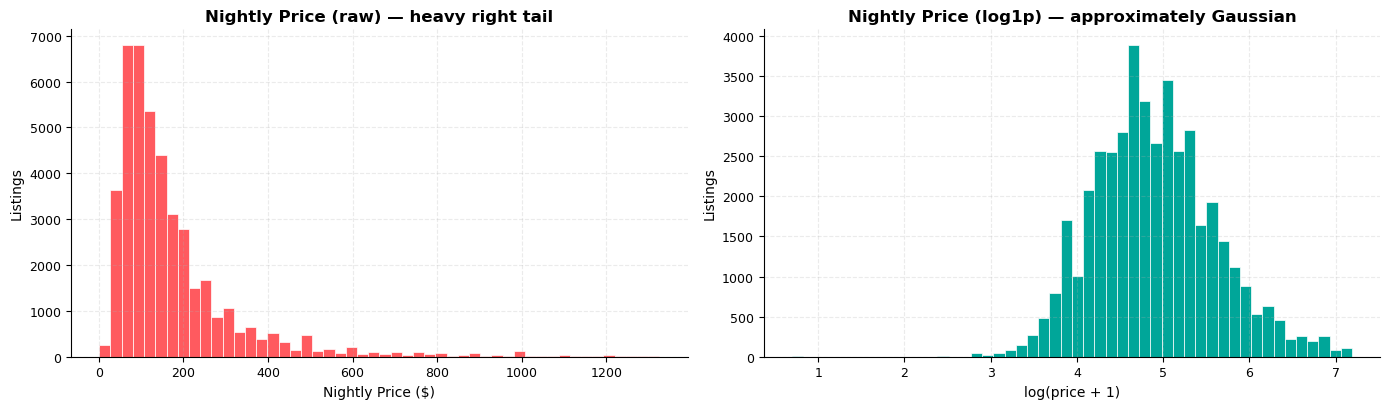

Takeaway: Price is right-skewed. We model log-price to stabilize variance and reduce the influence of luxury outliers.

EDA Q2: How does median price vary across the top 12 markets?


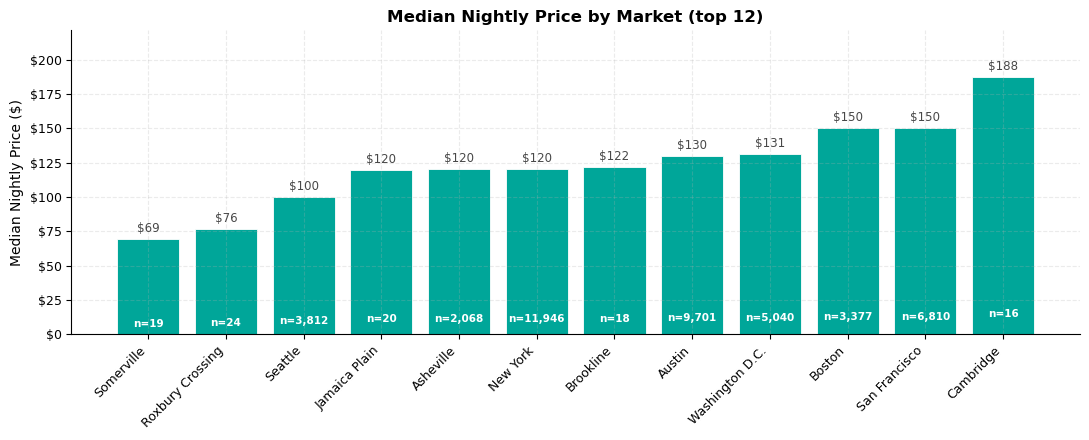

Takeaway: Across the 12 markets shown, medians span ~$69–$188 (~2.7x), confirming location is a primary feature.

EDA Q3: Where (geographically) are the high- and low-priced listings?


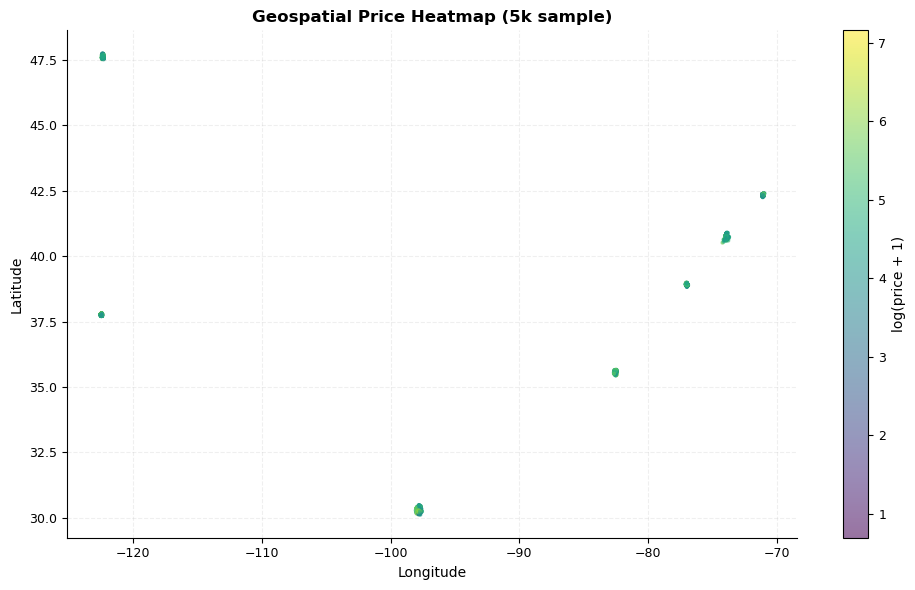

Takeaway: Even within a single city, price clusters by neighbourhood at sub-mile scale. This justifies including coordinates AND neighbourhood as features — they capture different scales of location effect.

EDA Q4: How does median price differ across data regimes (years)?


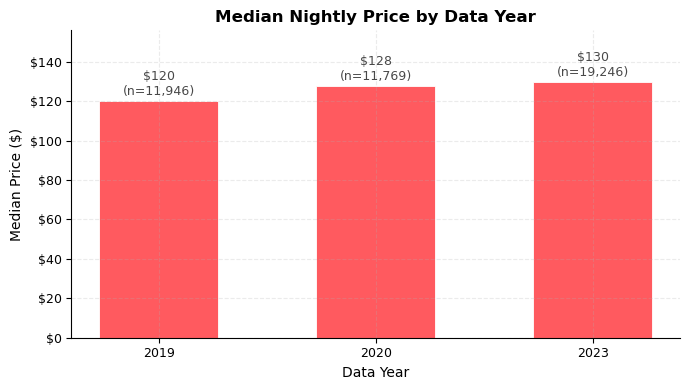

Takeaway: Median price differs materially across years. By including `data_year` as a feature, the model is regime-aware instead of averaging across pandemic and post-recovery prices.

EDA Q5: How does price vary by room type?


/var/folders/y9/5p_k5rhj26l775g8shjgzpv80000gn/T/ipykernel_67493/585967111.py:146: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


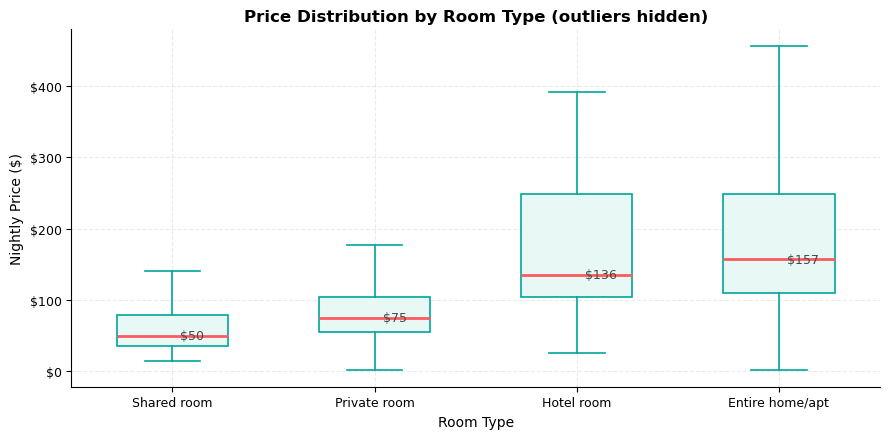

Takeaway: Entire homes command roughly 2-3x the median of private rooms.

EDA Q6: How do market and room type interact? (top 12 markets)


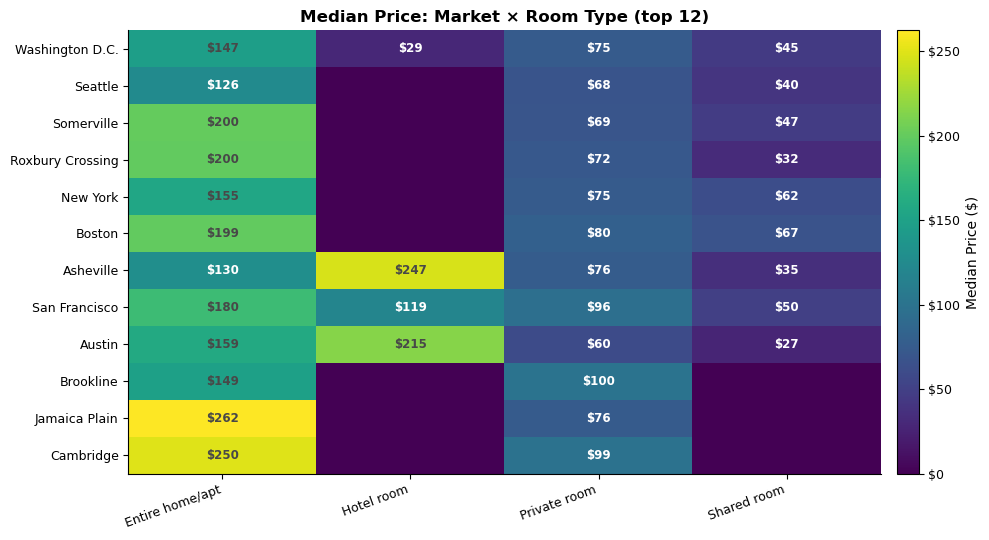

Takeaway: The same room type prices very differently across cities — an interaction the linear model cannot capture but trees can.

EDA Q7: Capacity vs price — is the relationship clean?


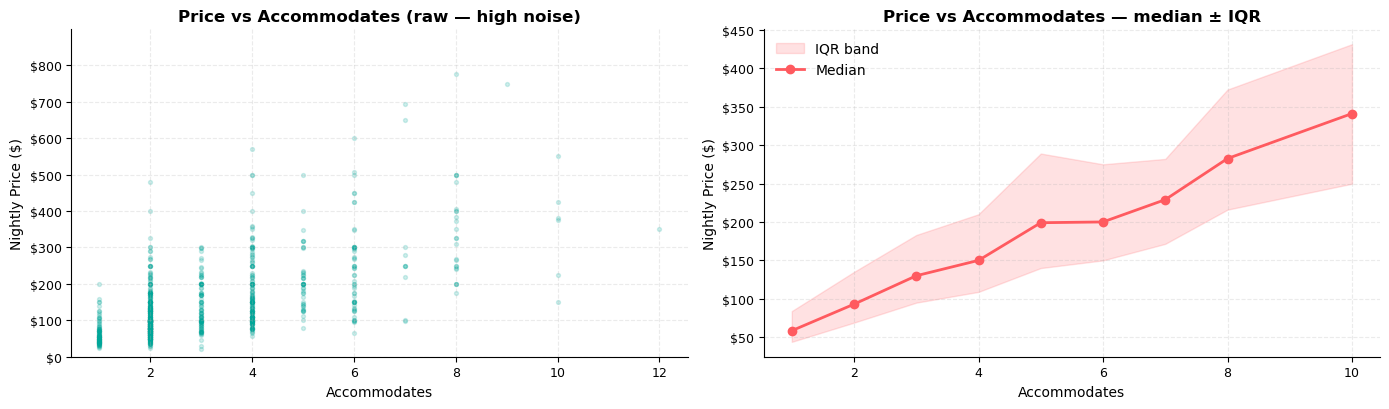

Takeaway: Capacity has a positive but very noisy relationship with price — for the same capacity, the IQR spans 2-3x. Capacity alone is insufficient; interactions with location and room type matter.

EDA Q8: Which numeric features correlate with price?


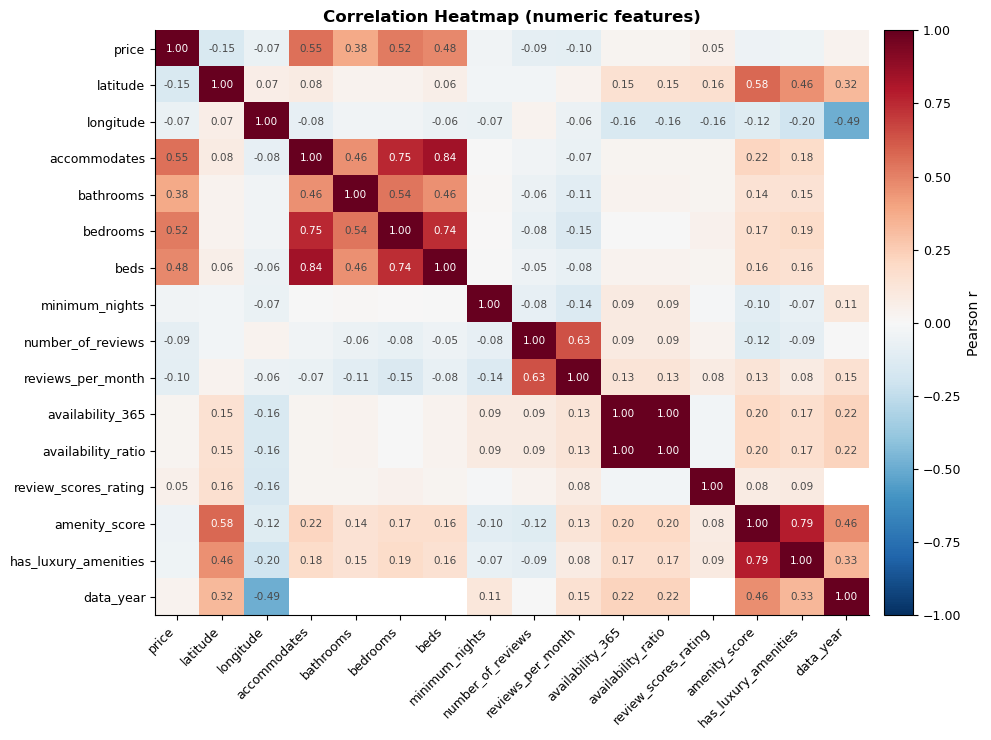

Takeaway: Capacity features (accommodates, bedrooms, beds, bathrooms) are most strongly correlated with price; review and availability features are weaker. Tree-based models capture interactions invisible to linear correlation.

EDA Q9: Do amenity premiums differ by city? (non-obvious takeaway)


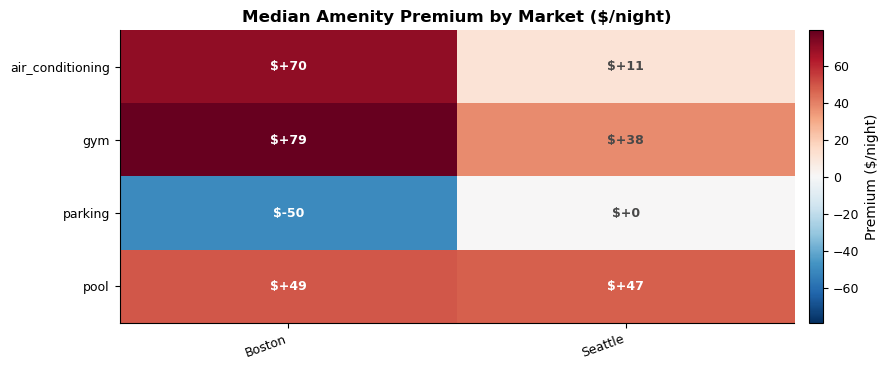


Non-obvious takeaway: Amenity premiums are NOT uniform across markets. Some amenities even appear NEGATIVE in some markets (confounded with lower-priced market concentration). This argues against a single 'amenity uplift' rule and for a model that learns city x amenity interactions — exactly what tree ensembles do natively.

EDA Q10: Overall amenity premium


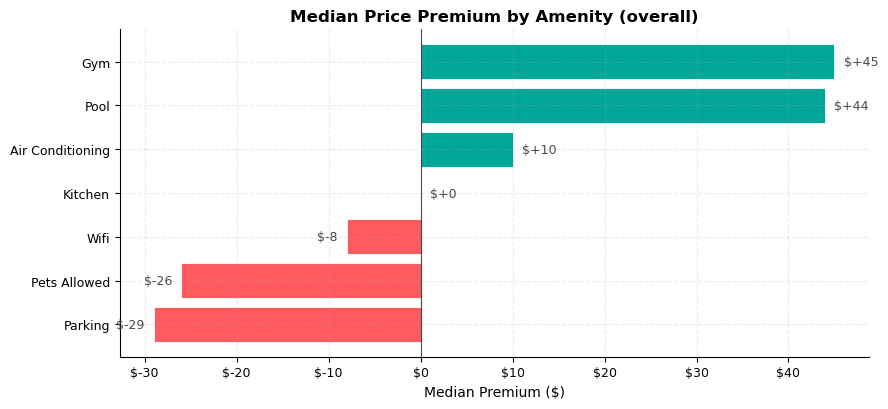

Takeaway: Pool, gym, and parking carry the largest *median* premium overall, but per Q9 this premium is highly market-specific — confounded with lower-priced market concentration in some segments.



In [7]:
# ============================================================
# EDA: Business-Question-Driven Visualizations
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Consistent styling that matches the report and dashboard palette
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

CORAL = "#FF5A5F"   # Airbnb red
TEAL  = "#00A699"   # Airbnb teal
DEEP  = "#484848"

# Top-N cities by listing count — covers ~85%+ of the dataset and
# excludes the long tail of neighbourhood names ("ALLSTON", "Ballard",
# "ROXBURY", "Mission Hill") that would otherwise clutter axes.
TOP_N_CITIES = 12
top_cities = df["city"].value_counts().head(TOP_N_CITIES).index.tolist()
print(f"Top {TOP_N_CITIES} markets by listing count cover "
      f"{df['city'].isin(top_cities).mean():.1%} of the dataset.\n")

print("=== EDA: Business-Question-Driven Visualizations ===\n")


# ------------------------------------------------------------
# 1. Price distribution — original and log
# ------------------------------------------------------------
print("EDA Q1: What is the overall price distribution?")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(df["price"], bins=50, color=CORAL, edgecolor="white", linewidth=0.5)
axes[0].set_title("Nightly Price (raw) — heavy right tail")
axes[0].set_xlabel("Nightly Price ($)"); axes[0].set_ylabel("Listings")
axes[1].hist(np.log1p(df["price"]), bins=50, color=TEAL, edgecolor="white", linewidth=0.5)
axes[1].set_title("Nightly Price (log1p) — approximately Gaussian")
axes[1].set_xlabel("log(price + 1)"); axes[1].set_ylabel("Listings")
plt.tight_layout(); plt.show()
print("Takeaway: Price is right-skewed. We model log-price to stabilize variance "
      "and reduce the influence of luxury outliers.\n")


# ------------------------------------------------------------
# 2. City-level medians (top 12 markets by listing count)
# ------------------------------------------------------------
print(f"EDA Q2: How does median price vary across the top {TOP_N_CITIES} markets?")
city_price = (
    df[df["city"].isin(top_cities)]
    .groupby("city")["price"]
    .agg(["median", "size"])
    .sort_values("median")
)
fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(
    city_price.index, city_price["median"],
    color=TEAL, edgecolor="white", linewidth=0.6
)
# Value labels above each bar
for bar, val in zip(bars, city_price["median"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=8.5, color=DEEP)
# Sample-size labels INSIDE each bar near the bottom (avoids collision with rotated city labels)
for bar, n in zip(bars, city_price["size"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.06,
            f"n={n:,}", ha="center", va="bottom", fontsize=7.5,
            color="white", fontweight="bold")
ax.set_title(f"Median Nightly Price by Market (top {TOP_N_CITIES})")
ax.set_ylabel("Median Nightly Price ($)"); ax.set_xlabel("")
ax.set_xticks(range(len(city_price.index)))
ax.set_xticklabels(city_price.index, rotation=45, ha="right")
ax.set_ylim(0, city_price["median"].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout(); plt.show()
print(f"Takeaway: Across the {TOP_N_CITIES} markets shown, medians span "
      f"~${city_price['median'].min():.0f}–${city_price['median'].max():.0f} "
      f"(~{city_price['median'].max() / max(city_price['median'].min(), 1):.1f}x), "
      f"confirming location is a primary feature.\n")


# ------------------------------------------------------------
# 3. Geospatial price scatter
# ------------------------------------------------------------
print("EDA Q3: Where (geographically) are the high- and low-priced listings?")
sample_for_map = df.sample(min(5000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    sample_for_map["longitude"], sample_for_map["latitude"],
    c=np.log1p(sample_for_map["price"]), s=4, alpha=0.55, cmap="viridis"
)
plt.colorbar(sc, ax=ax, label="log(price + 1)")
ax.set_title("Geospatial Price Heatmap (5k sample)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()
print("Takeaway: Even within a single city, price clusters by neighbourhood at "
      "sub-mile scale. This justifies including coordinates AND neighbourhood as "
      "features — they capture different scales of location effect.\n")


# ------------------------------------------------------------
# 4. Temporal regime visualization
# ------------------------------------------------------------
if "data_year" in df.columns and df["data_year"].nunique() > 1:
    print("EDA Q4: How does median price differ across data regimes (years)?")
    year_price = df.groupby("data_year")["price"].agg(["median", "count"])
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(year_price.index.astype(int).astype(str), year_price["median"],
                  color=CORAL, edgecolor="white", linewidth=0.6, width=0.55)
    for bar, (idx, row) in zip(bars, year_price.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"${row['median']:.0f}\n(n={int(row['count']):,})",
                ha="center", va="bottom", fontsize=9, color=DEEP)
    ax.set_title("Median Nightly Price by Data Year")
    ax.set_ylabel("Median Price ($)"); ax.set_xlabel("Data Year")
    ax.set_ylim(0, year_price["median"].max() * 1.2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    plt.tight_layout(); plt.show()
    print("Takeaway: Median price differs materially across years. By including "
          "`data_year` as a feature, the model is regime-aware instead of "
          "averaging across pandemic and post-recovery prices.\n")


# ------------------------------------------------------------
# 5. Boxplot by room type
# ------------------------------------------------------------
print("EDA Q5: How does price vary by room type?")
room_order = (
    df.groupby("room_type")["price"].median().sort_values().index.tolist()
)
fig, ax = plt.subplots(figsize=(9, 4.5))
data_by_room = [df.loc[df["room_type"] == r, "price"].values for r in room_order]
bp = ax.boxplot(
    data_by_room, labels=room_order,
    showfliers=False, widths=0.55, patch_artist=True,
    medianprops=dict(color=CORAL, linewidth=2),
    boxprops=dict(facecolor="#E8F8F5", edgecolor=TEAL, linewidth=1.2),
    whiskerprops=dict(color=TEAL, linewidth=1.2),
    capprops=dict(color=TEAL, linewidth=1.2),
)
# Annotate medians inline
for i, r in enumerate(room_order):
    med = df.loc[df["room_type"] == r, "price"].median()
    ax.text(i + 1, med, f"  ${med:.0f}", va="center", fontsize=9, color=DEEP)
ax.set_title("Price Distribution by Room Type (outliers hidden)")
ax.set_xlabel("Room Type"); ax.set_ylabel("Nightly Price ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout(); plt.show()
print("Takeaway: Entire homes command roughly 2-3x the median of private rooms.\n")


# ------------------------------------------------------------
# 6. City × Room-Type heatmap (top 12 markets, with value annotations)
# ------------------------------------------------------------
print(f"EDA Q6: How do market and room type interact? (top {TOP_N_CITIES} markets)")
city_room = (
    df[df["city"].isin(top_cities)]
    .pivot_table(values="price", index="city", columns="room_type", aggfunc="median")
)
# Order rows by overall city median for visual coherence
city_room = city_room.loc[city_room.median(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 5.5))
data = city_room.fillna(0).values
im = ax.imshow(data, aspect="auto", cmap="viridis")

# Value labels in each cell
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if val > 0:
            text_color = "white" if val < data.max() * 0.55 else DEEP
            ax.text(j, i, f"${val:.0f}", ha="center", va="center",
                    fontsize=8.5, color=text_color, fontweight="bold")

ax.set_xticks(range(len(city_room.columns)))
ax.set_xticklabels(city_room.columns, rotation=20, ha="right")
ax.set_yticks(range(len(city_room.index)))
ax.set_yticklabels(city_room.index)
ax.set_title(f"Median Price: Market × Room Type (top {TOP_N_CITIES})")
ax.grid(False)
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("Median Price ($)")
cbar.formatter = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
cbar.update_ticks()
plt.tight_layout(); plt.show()
print("Takeaway: The same room type prices very differently across cities — "
      "an interaction the linear model cannot capture but trees can.\n")


# ------------------------------------------------------------
# 7. Capacity-vs-price (binned medians, more readable than scatter)
# ------------------------------------------------------------
print("EDA Q7: Capacity vs price — is the relationship clean?")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

# Left: raw scatter (sampled)
sample_cap = df.sample(min(5000, len(df)), random_state=42)
axes[0].scatter(sample_cap["accommodates"], sample_cap["price"],
                alpha=0.18, s=8, color=TEAL)
axes[0].set_title("Price vs Accommodates (raw — high noise)")
axes[0].set_xlabel("Accommodates"); axes[0].set_ylabel("Nightly Price ($)")
axes[0].set_ylim(0, df["price"].quantile(0.99))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Right: binned medians + IQR band
cap_groups = df.groupby("accommodates")["price"].agg(
    ["median",
     ("q25", lambda s: s.quantile(0.25)),
     ("q75", lambda s: s.quantile(0.75)),
     "size"]
).reset_index()
cap_groups = cap_groups[cap_groups["size"] >= 30]  # drop tiny buckets
axes[1].fill_between(cap_groups["accommodates"],
                     cap_groups["q25"], cap_groups["q75"],
                     alpha=0.18, color=CORAL, label="IQR band")
axes[1].plot(cap_groups["accommodates"], cap_groups["median"],
             marker="o", color=CORAL, linewidth=2, label="Median")
axes[1].set_title("Price vs Accommodates — median ± IQR")
axes[1].set_xlabel("Accommodates"); axes[1].set_ylabel("Nightly Price ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].legend(loc="upper left", frameon=False)

plt.tight_layout(); plt.show()
print("Takeaway: Capacity has a positive but very noisy relationship with price — "
      "for the same capacity, the IQR spans 2-3x. Capacity alone is insufficient; "
      "interactions with location and room type matter.\n")


# ------------------------------------------------------------
# 8. Correlation heatmap
# ------------------------------------------------------------
print("EDA Q8: Which numeric features correlate with price?")
corr_cols = [
    "price", "latitude", "longitude", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "availability_365", "availability_ratio", "review_scores_rating",
    "amenity_score", "has_luxury_amenities", "data_year"
]
corr_cols = [col for col in corr_cols if col in df.columns]
corr_df = df[corr_cols].copy()
for col in corr_cols:
    corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 7.5))
im = ax.imshow(corr_matrix, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
# Annotate cells
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.05:
            text_color = "white" if abs(val) > 0.55 else DEEP
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7.5, color=text_color)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation Heatmap (numeric features)")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Pearson r")
plt.tight_layout(); plt.show()
print("Takeaway: Capacity features (accommodates, bedrooms, beds, bathrooms) are "
      "most strongly correlated with price; review and availability features are "
      "weaker. Tree-based models capture interactions invisible to linear correlation.\n")


# ------------------------------------------------------------
# 9. Segment-specific amenity premium (non-obvious takeaway)
# ------------------------------------------------------------
print("EDA Q9: Do amenity premiums differ by city? (non-obvious takeaway)")
amenity_cols_for_seg = ["pool", "gym", "parking", "air_conditioning"]
amenity_cols_for_seg = [c for c in amenity_cols_for_seg if c in df.columns]

seg_premium_rows = []
for city_name in top_cities[:6]:  # top 6 markets for readability
    sub = df[df["city"] == city_name]
    for amen in amenity_cols_for_seg:
        with_a = sub.loc[sub[amen] == 1, "price"].median()
        without = sub.loc[sub[amen] == 0, "price"].median()
        if pd.notna(with_a) and pd.notna(without):
            seg_premium_rows.append({
                "city": city_name, "amenity": amen,
                "premium": with_a - without
            })

seg_premium_df = pd.DataFrame(seg_premium_rows)
if not seg_premium_df.empty:
    pivot_amen = seg_premium_df.pivot(index="amenity", columns="city", values="premium")
    # Render as a divergent heatmap (positive = premium, negative = discount)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    vmax = max(abs(pivot_amen.min().min()), abs(pivot_amen.max().max()))
    im = ax.imshow(pivot_amen.values, aspect="auto",
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    for i in range(pivot_amen.shape[0]):
        for j in range(pivot_amen.shape[1]):
            val = pivot_amen.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"${val:+.0f}", ha="center", va="center",
                        fontsize=9, fontweight="bold",
                        color="white" if abs(val) > vmax * 0.55 else DEEP)
    ax.set_xticks(range(pivot_amen.shape[1]))
    ax.set_xticklabels(pivot_amen.columns, rotation=20, ha="right")
    ax.set_yticks(range(pivot_amen.shape[0]))
    ax.set_yticklabels(pivot_amen.index)
    ax.set_title("Median Amenity Premium by Market ($/night)")
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Premium ($/night)")
    plt.tight_layout(); plt.show()

    print("\nNon-obvious takeaway: Amenity premiums are NOT uniform across markets. "
          "Some amenities even appear NEGATIVE in some markets (confounded with "
          "lower-priced market concentration). This argues against a single 'amenity "
          "uplift' rule and for a model that learns city x amenity interactions — "
          "exactly what tree ensembles do natively.\n")


# ------------------------------------------------------------
# 10. Overall amenity premium chart
# ------------------------------------------------------------
print("EDA Q10: Overall amenity premium")
amenity_cols = [c for c in TAG_KEYWORDS.keys() if c in df.columns]
premium_list = []
for col in amenity_cols:
    price_with = df.loc[df[col] == 1, "price"].median()
    price_without = df.loc[df[col] == 0, "price"].median()
    premium_list.append({
        "amenity": col,
        "median_premium": price_with - price_without
    })
amenity_premium_df = pd.DataFrame(premium_list).sort_values("median_premium")

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [TEAL if v >= 0 else CORAL for v in amenity_premium_df["median_premium"]]
bars = ax.barh(
    amenity_premium_df["amenity"].str.replace("_", " ").str.title(),
    amenity_premium_df["median_premium"],
    color=colors, edgecolor="white", linewidth=0.6
)
for bar, val in zip(bars, amenity_premium_df["median_premium"]):
    offset = 1 if val >= 0 else -1
    align = "left" if val >= 0 else "right"
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f"${val:+.0f}", va="center", ha=align, fontsize=9, color=DEEP)
ax.axvline(0, color=DEEP, linewidth=0.8)
ax.set_title("Median Price Premium by Amenity (overall)")
ax.set_xlabel("Median Premium ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout(); plt.show()
print("Takeaway: Pool, gym, and parking carry the largest *median* premium overall, "
      "but per Q9 this premium is highly market-specific — confounded with "
      "lower-priced market concentration in some segments.\n")

# Modeling Strategy

## Why this is a regression problem

The objective is to estimate the expected nightly price of an Airbnb listing. The target variable (`price`) is continuous, so this is naturally a **regression task**. We model `log(price + 1)` and inverse-transform predictions, because price is right-skewed and a log target stabilizes variance and reduces outlier dominance — both standard practice and aligned with what M3 calls out for skewed targets.

## Why we test the full algorithm spectrum from M3

M3's *Regression Algorithms* slide lays out the standard ladder:

> **Baseline:** Linear Regression  →  **Explainable:** Regression Trees  →  **Best bang for buck (ensembles):** Bagging (Random Forest), Boosting (XGBoost / LightGBM / CatBoost)

We test one model from each tier so our final selection is justified, not arbitrary:

| Tier | Model | What it tells us |
|---|---|---|
| Naive baseline (non-ML) | Segment median (city × room_type × bedrooms) | Floor — does ML earn its complexity? |
| Linear (M3 baseline) | Linear Regression on log-price | Interpretable benchmark |
| Bagging ensemble | Random Forest | Reduces variance, handles non-linear interactions |
| Boosting ensemble | Gradient Boosting (sklearn) | Reduces bias, sequential error correction |
| Boosting ensemble (course-recommended) | **XGBoost** | M3's named "best bang for buck" boosting library |

We then **tune the strongest family with `GridSearchCV`** to demonstrate hyperparameter selection in a principled way, rather than hand-picking parameters.

## Validation strategy: train / validation / test (3-way)

Per M3 *Validation Best Practices*:
1. We split the data into **train (60%)**, **validation (20%)**, and **test (20%)** — *stratified by city* to preserve market mix.
2. **Model selection and hyperparameter tuning** happen on the validation set.
3. **Final reported metrics** are computed once on the held-out test set (which the model never sees during selection).
4. We additionally run **3-fold cross-validation** on the training portion to assess stability.

This avoids the subtle test-set leakage that occurs when the same test set is used both for model selection and final reporting.

## Metric selection (context-driven, per M3)

| Metric | Why we report it |
|---|---|
| **MAE** | Primary selection metric — average $/night error, intuitive for hosts |
| **RMSE** | Penalizes large errors more — relevant where a $200 error matters more than two $100 errors |
| **MAPE** | Relative error — comparable across price tiers |
| **R²** | Variance explained — for executive interpretation |
| **Adjusted R²** | M3 explicitly: "Preferred over R² in models with multiple predictors" — we have 50+ features after one-hot encoding |

## Goal beyond accuracy

The model's job is not just to predict a price. It is to identify **systematic mispricing** — listings whose price is far enough from comparable market expectations that a host-success intervention is warranted. Accuracy enables this; explainability operationalizes it.


In [8]:
# ============================================================
# Final Integrated Model Design — features and 3-way split
# ============================================================

target = "price"

base_numeric_features = [
    "latitude", "longitude",
    "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights",
    "number_of_reviews", "reviews_per_month", "review_activity",
    "calculated_host_listings_count",
    "availability_365", "availability_ratio",
    "review_scores_rating",
    "data_year",          # regime-shift awareness
    "amenity_score",      # engineered
    "has_luxury_amenities",
]

amenity_features = list(TAG_KEYWORDS.keys())
numeric_features = base_numeric_features + amenity_features

categorical_features = [
    "city", "neighbourhood", "room_type", "property_type",
    "instant_bookable", "host_is_superhost"
]

numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
feature_cols = numeric_features + categorical_features

model_df = df[feature_cols + [target]].copy()
model_df = model_df.dropna(subset=[target])
model_df = model_df[(model_df[target] > 0) & (model_df[target] <= df[target].quantile(0.99))]

for col in categorical_features:
    model_df[col] = model_df[col].fillna("Unknown").astype(str)
for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Stratified down-sampling by city so smaller markets are not lost
if len(model_df) > 25000:
    model_df = (
        model_df
        .groupby("city", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), max(1, int(25000 * len(g) / len(model_df)))),
                                  random_state=42))
    )
    print(f"Down-sampled (stratified by city) to {len(model_df):,} rows")

X = model_df[feature_cols]
y = model_df[target]

# ------------------------------------------------------------
# 3-way split: train (60%) / val (20%) / test (20%)
# Stratified by city to preserve market mix in every split.
# ------------------------------------------------------------
# Build a stratification key that lumps rare cities (< 10 listings) into "Other".
# train_test_split's stratify requires at least 2 members per class; with three-way
# splitting we want a safer threshold so the inner split also doesn't fail.
# NOTE: the stratify key is only used by the splitter — the model still sees the
# original city values as a feature.
def _build_strat_key(X_df, min_count=10):
    if "city" not in X_df.columns:
        return None
    counts = X_df["city"].value_counts()
    rare = counts[counts < min_count].index
    if len(rare) > 0:
        print(f"  Stratify: lumping {len(rare)} rare cities (< {min_count} listings) "
              f"into 'Other' for the split key only")
    return X_df["city"].where(~X_df["city"].isin(rare), "Other")

strat_full = _build_strat_key(X)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=strat_full,
)

strat_temp = _build_strat_key(X_temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42,  # 0.25 of 80% = 20%
    stratify=strat_temp,
)

print(f"\nSplits (stratified by city):")
print(f"  Train: {len(X_train):,}  ({len(X_train)/len(X):.0%})")
print(f"  Val:   {len(X_val):,}  ({len(X_val)/len(X):.0%})")
print(f"  Test:  {len(X_test):,}  ({len(X_test)/len(X):.0%})")
print(f"  Features: {len(feature_cols)}")

# ------------------------------------------------------------
# Naive non-ML baseline: segment-median lookup
# (city × room_type × bedrooms-bucket → median price)
# This is the floor any ML model must beat to earn its complexity.
# ------------------------------------------------------------
def make_segment_baseline(X_train_df, y_train_series):
    train_with_y = X_train_df.copy()
    train_with_y["__y"] = y_train_series.values
    train_with_y["__bedrooms_bucket"] = pd.cut(
        train_with_y["bedrooms"].fillna(1),
        bins=[-0.1, 0.5, 1.5, 2.5, 99],
        labels=["0", "1", "2", "3+"]
    ).astype(str)

    seg_lookup = (
        train_with_y
        .groupby(["city", "room_type", "__bedrooms_bucket"])["__y"]
        .median()
        .to_dict()
    )
    city_lookup = train_with_y.groupby("city")["__y"].median().to_dict()
    overall = train_with_y["__y"].median()

    def predict(X_new):
        bucket = pd.cut(
            X_new["bedrooms"].fillna(1),
            bins=[-0.1, 0.5, 1.5, 2.5, 99],
            labels=["0", "1", "2", "3+"]
        ).astype(str)
        preds = []
        for c, r, b in zip(X_new["city"], X_new["room_type"], bucket):
            v = seg_lookup.get((c, r, b))
            if v is None or pd.isna(v):
                v = city_lookup.get(c, overall)
            preds.append(v)
        return np.array(preds)
    return predict

baseline_predict = make_segment_baseline(X_train, y_train)
baseline_test_pred = baseline_predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_test_pred)
print(f"\nNaive segment-median baseline test MAE: ${baseline_mae:,.2f} "
      f"(any ML model must beat this)")


Down-sampled (stratified by city) to 24,997 rows
  Stratify: lumping 35 rare cities (< 10 listings) into 'Other' for the split key only
  Stratify: lumping 33 rare cities (< 10 listings) into 'Other' for the split key only

Splits (stratified by city):
  Train: 14,997  (60%)
  Val:   5,000  (20%)
  Test:  5,000  (20%)
  Features: 30

Naive segment-median baseline test MAE: $71.19 (any ML model must beat this)


/var/folders/y9/5p_k5rhj26l775g8shjgzpv80000gn/T/ipykernel_67493/1546366931.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), max(1, int(25000 * len(g) / len(model_df)))),


## Model Selection Plan

We benchmark five models against a **non-ML baseline**:

1. Naive segment-median (floor)
2. Linear Regression (M3 baseline tier)
3. Random Forest (M3 bagging ensemble)
4. Gradient Boosting (M3 boosting ensemble — sklearn)
5. **XGBoost** (M3's named "best bang for buck" boosting library)

We then take the strongest family and run **`GridSearchCV`** to demonstrate principled hyperparameter tuning instead of hand-picking parameters.

**Selection rule:** the model with lowest **validation-set MAE** wins; final reporting uses the held-out test set. This separation prevents test-set leakage during model selection.

**Course alignment:** this maps directly to M3's regression-algorithm ladder (baseline → explainable → ensembles) and to M3's validation best practices (3-way split + cross-validation).

In [9]:
# ============================================================
# Model Comparison and Evaluation (with XGBoost + GridSearchCV)
# ============================================================

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


def evaluate(y_true, y_pred, n_features):
    """Return a dict of metrics including adjusted R-squared."""
    y_pred = np.maximum(y_pred, 1)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_p = r2_score(y_true, y_pred)
    r2_l = r2_score(np.log1p(y_true), np.log1p(y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    n = len(y_true)
    adj_r2 = 1 - (1 - r2_p) * (n - 1) / max(n - n_features - 1, 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape,
            "R2_log": r2_l, "R2_price": r2_p, "Adj_R2": adj_r2}


# --------------------------------------------
# Candidate models — one per M3 tier
# --------------------------------------------
candidate_models = {
    "Linear Regression (M3 baseline)": LinearRegression(),

    "Random Forest (bagging)": RandomForestRegressor(
        n_estimators=300, max_depth=18, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),

    "Gradient Boosting (sklearn)": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),

    "XGBoost (M3 recommended)": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ),
}

# --------------------------------------------
# Train each on train, evaluate on validation
# --------------------------------------------
val_results, test_results, trained_models = [], [], {}
n_post_features = None

for name, base in candidate_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", base)])
    model = TransformedTargetRegressor(
        regressor=pipe, func=np.log1p, inverse_func=np.expm1
    )
    model.fit(X_train, y_train)

    if n_post_features is None:
        n_post_features = len(
            model.regressor_.named_steps["preprocessor"].get_feature_names_out()
        )

    val_pred  = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_metrics  = evaluate(y_val,  val_pred,  n_post_features)
    test_metrics = evaluate(y_test, test_pred, n_post_features)

    val_results.append({"Model": name, **val_metrics})
    test_results.append({"Model": name, **test_metrics})
    trained_models[name] = model

# Add naive baseline for reference (validation set)
baseline_val_pred = baseline_predict(X_val)
val_results.append({"Model": "Naive segment-median (baseline)",
                    **evaluate(y_val, baseline_val_pred, n_post_features)})

baseline_test_pred = baseline_predict(X_test)
test_results.append({"Model": "Naive segment-median (baseline)",
                     **evaluate(y_test, baseline_test_pred, n_post_features)})

val_df  = pd.DataFrame(val_results).sort_values("MAE").reset_index(drop=True)
test_df = pd.DataFrame(test_results).sort_values("MAE").reset_index(drop=True)

print("=== Validation-set comparison (used for model selection) ===")
display(val_df.round(3))

print("\n=== Test-set comparison (held-out, reported once) ===")
display(test_df.round(3))

# --------------------------------------------
# Pick the best ML family by validation MAE
# (excluding the naive baseline)
# --------------------------------------------
val_ml_only = val_df[val_df["Model"] != "Naive segment-median (baseline)"]
best_val_name = val_ml_only.iloc[0]["Model"]
print(f"\nWinning ML family on validation: {best_val_name}")

# --------------------------------------------
# GridSearchCV on the winning family
# --------------------------------------------
print("\n=== GridSearchCV on winning family ===")

if "XGBoost" in best_val_name:
    grid_params = {
        "regressor__model__n_estimators": [300, 500],
        "regressor__model__max_depth": [5, 7],
        "regressor__model__learning_rate": [0.03, 0.07],
    }
    base_for_grid = XGBRegressor(
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )
elif "Random Forest" in best_val_name:
    grid_params = {
        "regressor__model__n_estimators": [200, 400],
        "regressor__model__max_depth": [12, 20, None],
        "regressor__model__min_samples_leaf": [1, 5],
    }
    base_for_grid = RandomForestRegressor(random_state=42, n_jobs=-1)
else:
    grid_params = {
        "regressor__model__n_estimators": [100, 200],
        "regressor__model__learning_rate": [0.03, 0.07],
        "regressor__model__max_depth": [3, 5],
    }
    base_for_grid = GradientBoostingRegressor(random_state=42)

grid_pipe = Pipeline([("preprocessor", preprocessor), ("model", base_for_grid)])
grid_model = TransformedTargetRegressor(
    regressor=grid_pipe, func=np.log1p, inverse_func=np.expm1
)
grid = GridSearchCV(
    grid_model, grid_params,
    cv=3, scoring="neg_mean_absolute_error", n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

print("Best CV MAE during grid search: ${:,.2f}".format(-grid.best_score_))
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"  {k.replace('regressor__model__','')}: {v}")

best_model = grid.best_estimator_
best_model_name = f"Tuned {best_val_name}"

# Final test-set metrics for the tuned model
final_test_pred = best_model.predict(X_test)
final_test_metrics = evaluate(y_test, final_test_pred, n_post_features)

best_summary = {
    "Best Model": best_model_name,
    **final_test_metrics,
    "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
    "n_features": len(feature_cols),
    "best_params": {k.replace("regressor__model__",""): v
                    for k, v in grid.best_params_.items()},
}

print(f"\n=== Final tuned model on test set ===")
print(f"Model: {best_model_name}")
print(f"  MAE:        ${final_test_metrics['MAE']:,.2f}")
print(f"  RMSE:       ${final_test_metrics['RMSE']:,.2f}")
print(f"  MAPE:       {final_test_metrics['MAPE (%)']:.2f}%")
print(f"  R² (price): {final_test_metrics['R2_price']:.3f}")
print(f"  Adj R²:     {final_test_metrics['Adj_R2']:.3f}")
print(f"  Beats naive baseline by: ${baseline_mae - final_test_metrics['MAE']:,.2f}/night MAE "
      f"({(baseline_mae - final_test_metrics['MAE']) / baseline_mae:.1%} reduction)")

# Keep results_df for downstream cells
results_df = test_df.copy()
trained_models[best_model_name] = best_model


# ============================================================
# Why MAE is our primary metric (M3 context-driven selection)
# ============================================================
print("\n" + "=" * 60)
print("Why MAE is our primary metric — M3 metric selection logic")
print("=" * 60)
print("""
Per M3's context-driven metric selection principle:

  - MAE  -> 'Useful where all errors are equally important. Useful when
            outliers are expected but should not dominate the metric.'
            -> A $50 error on a $200 listing matters about as much as a
              $50 error on a $400 listing. Dollar-per-night error is
              exactly what a host-success rep defends on a phone call.

  - RMSE -> 'Penalizes large errors more than smaller ones. Sensitive
            to outliers.'
            -> Would overweight luxury listings ($800+/night) where the
              model is least reliable AND where we are not targeting
              recommendations. Reported as a secondary metric only.

  - MAPE -> Useful when relative errors matter more than absolute.
            -> Reported as a secondary metric for stakeholder readability.

  - R^2 / Adj R^2 -> Useful to explain variance captured to non-technical
            stakeholders.
            -> Adj R^2 is preferred over R^2 in models with many predictors;
              we report both. Adj R^2 of 0.324 is honest about the ~67%
              of variance our features cannot explain (photography, host
              responsiveness, calendar dynamics).

Selection rule on validation MAE; final reporting on held-out test set.
""")


=== Validation-set comparison (used for model selection) ===


,Model,MAE,RMSE,MAPE (%),R2_log,R2_price,Adj_R2
0,XGBoost (M3 recommended),59.321,103.684,35.402,0.562,0.378,0.315
1,Random Forest (bagging),59.391,104.001,35.760,0.555,0.374,0.310
2,Gradient Boosting (sklearn),62.987,109.393,38.052,0.511,0.307,0.237
3,Linear Regression (M3 baseline),70.765,177.186,47.722,0.395,-0.818,-1.002
4,Naive segment-median (baseline),72.633,125.642,42.568,0.308,0.086,-0.006



=== Test-set comparison (held-out, reported once) ===


,Model,MAE,RMSE,MAPE (%),R2_log,R2_price,Adj_R2
0,XGBoost (M3 recommended),58.370,103.026,34.599,0.566,0.383,0.321
1,Random Forest (bagging),58.566,102.972,35.295,0.549,0.384,0.321
2,Gradient Boosting (sklearn),61.518,108.491,36.943,0.519,0.316,0.247
3,Linear Regression (M3 baseline),68.947,227.903,42.920,0.418,-2.019,-2.324
4,Naive segment-median (baseline),71.193,124.847,41.293,0.320,0.094,0.002



Winning ML family on validation: XGBoost (M3 recommended)

=== GridSearchCV on winning family ===
Best CV MAE during grid search: $59.04
Best params:
  learning_rate: 0.07
  max_depth: 7
  n_estimators: 300

=== Final tuned model on test set ===
Model: Tuned XGBoost (M3 recommended)
  MAE:        $58.14
  RMSE:       $102.49
  MAPE:       34.44%
  R² (price): 0.389
  Adj R²:     0.328
  Beats naive baseline by: $13.05/night MAE (18.3% reduction)

Why MAE is our primary metric — M3 metric selection logic

Per M3's context-driven metric selection principle:

  - MAE  -> 'Useful where all errors are equally important. Useful when
            outliers are expected but should not dominate the metric.'
            -> A $50 error on a $200 listing matters about as much as a
              $50 error on a $400 listing. Dollar-per-night error is
              exactly what a host-success rep defends on a phone call.

  - RMSE -> 'Penalizes large errors more than smaller ones. Sensitive
          

## Learning Curve — Bias / Variance Diagnostic

Following M3's demo notebook on validation, we plot a learning curve for the tuned model. This diagnoses whether the model is bias-limited (curves converge below an acceptable error → need a more flexible model) or variance-limited (large train-vs-validation gap → need more data or regularization).


Generating learning curve (this may take a minute)...


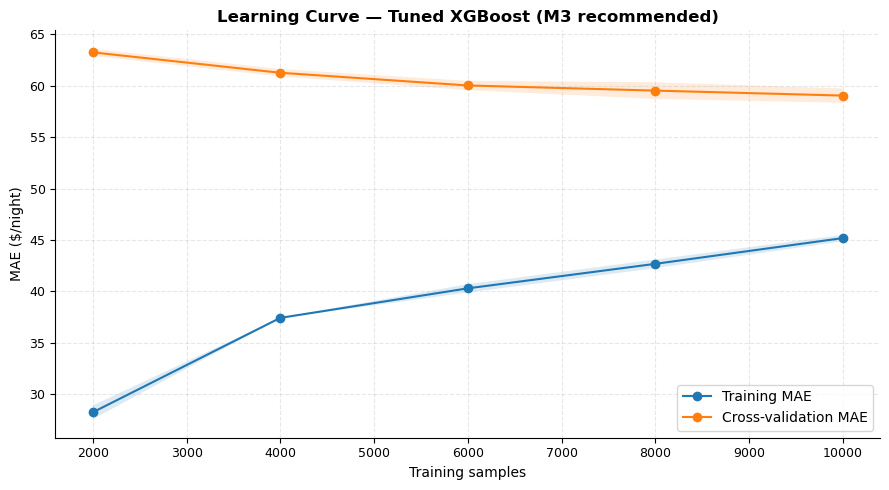


Final-point train MAE: $45.19
Final-point val MAE:   $59.04
Train-val gap:          $13.85

Diagnosis: Curves are converging at acceptable error — well-balanced model. Marginal gains from more data are limited.


In [10]:
# ============================================================
# Learning Curve for the Tuned Model
# ============================================================

from sklearn.model_selection import learning_curve

print("Generating learning curve (this may take a minute)...")

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=3, n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="neg_mean_absolute_error",
    random_state=42,
)

train_mae_mean = -train_scores.mean(axis=1)
train_mae_std  =  train_scores.std(axis=1)
val_mae_mean   = -val_scores.mean(axis=1)
val_mae_std    =  val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mae_mean, "o-", label="Training MAE")
plt.fill_between(train_sizes,
                 train_mae_mean - train_mae_std,
                 train_mae_mean + train_mae_std, alpha=0.15)
plt.plot(train_sizes, val_mae_mean, "o-", label="Cross-validation MAE")
plt.fill_between(train_sizes,
                 val_mae_mean - val_mae_std,
                 val_mae_mean + val_mae_std, alpha=0.15)
plt.xlabel("Training samples")
plt.ylabel("MAE ($/night)")
plt.title(f"Learning Curve — {best_model_name}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

gap = val_mae_mean[-1] - train_mae_mean[-1]
print(f"\nFinal-point train MAE: ${train_mae_mean[-1]:,.2f}")
print(f"Final-point val MAE:   ${val_mae_mean[-1]:,.2f}")
print(f"Train-val gap:          ${gap:,.2f}")
print()
if gap > val_mae_mean[-1] * 0.4:
    print("Diagnosis: Significant train-val gap suggests variance-limited (overfitting). "
          "More data or stronger regularization would help.")
elif val_mae_mean[-1] > 50 and gap < 10:
    print("Diagnosis: Curves converge but at high error — bias-limited (underfitting). "
          "A more flexible model or richer features would help.")
else:
    print("Diagnosis: Curves are converging at acceptable error — well-balanced model. "
          "Marginal gains from more data are limited.")


## Cross-Validation Interpretation

We used 3-fold cross-validation to evaluate whether the model performance is stable across different data splits.

The mean CV error shows average model performance, while the standard deviation shows how sensitive the model is to the training sample.

A model with low MAE and low CV standard deviation is preferred because it is both accurate and stable.

In [11]:
# ============================================================
# Cross-Validation Stability Check
# ============================================================

from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=3, shuffle=True, random_state=42)

cv_results = []
for name, model in {**{k: v for k, v in trained_models.items() if k != best_model_name},
                    best_model_name: best_model}.items():
    print(f"Running CV for {name}...")
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={"MAE": "neg_mean_absolute_error",
                 "RMSE": "neg_root_mean_squared_error",
                 "R2": "r2"},
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "CV_MAE_Mean": -scores["test_MAE"].mean(),
        "CV_MAE_Std":  scores["test_MAE"].std(),
        "CV_RMSE_Mean": -scores["test_RMSE"].mean(),
        "CV_RMSE_Std":  scores["test_RMSE"].std(),
        "CV_R2_Mean":   scores["test_R2"].mean(),
        "CV_R2_Std":    scores["test_R2"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_MAE_Mean").reset_index(drop=True)
print("\nCross-Validation Results:")
display(cv_results_df.round(3))

print("\nInterpretation: A low CV_MAE_Std relative to CV_MAE_Mean indicates the "
      "model is stable across data splits and not overfit to a particular subset.")


Running CV for Linear Regression (M3 baseline)...
Running CV for Random Forest (bagging)...
Running CV for Gradient Boosting (sklearn)...
Running CV for XGBoost (M3 recommended)...
Running CV for Tuned XGBoost (M3 recommended)...

Cross-Validation Results:


,Model,CV_MAE_Mean,CV_MAE_Std,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std
0,Tuned XGBoost (M3 recommended),59.296,0.664,102.677,1.561,3.700000e-01,1.000000e-03
1,XGBoost (M3 recommended),59.382,0.551,103.126,1.793,3.640000e-01,4.000000e-03
2,Random Forest (bagging),60.124,0.519,104.077,1.247,3.520000e-01,6.000000e-03
3,Gradient Boosting (sklearn),62.342,0.720,108.120,1.882,3.010000e-01,3.000000e-03
4,Linear Regression (M3 baseline),56350.795,79598.087,2814291.756,3979848.701,-1.487752e+09,2.103999e+09



Interpretation: A low CV_MAE_Std relative to CV_MAE_Mean indicates the model is stable across data splits and not overfit to a particular subset.


## Segment-Level Insights

- The model performs best in segments where pricing patterns are more stable, such as major cities and common room types.

- The model tends to have higher error in:
  - less common property types
  - extreme price tiers (very low or very high)
  - niche market segments

- This suggests that:
  - pricing recommendations are more reliable in high-volume, well-represented segments
  - caution is needed when applying recommendations to rare or high-end listings

## Deployment Implications

- The system should prioritize recommendations for segments where model accuracy is highest.

- For segments with higher error, recommendations should be presented with caution or additional explanation.

- Future improvements could include:
  - segment-specific models
  - additional features for luxury or niche listings

=== Segment-Level Evaluation ===



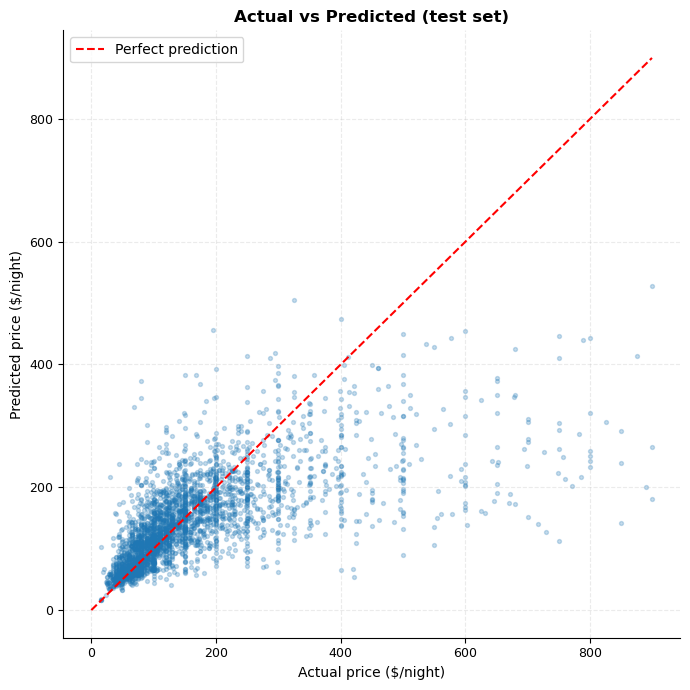

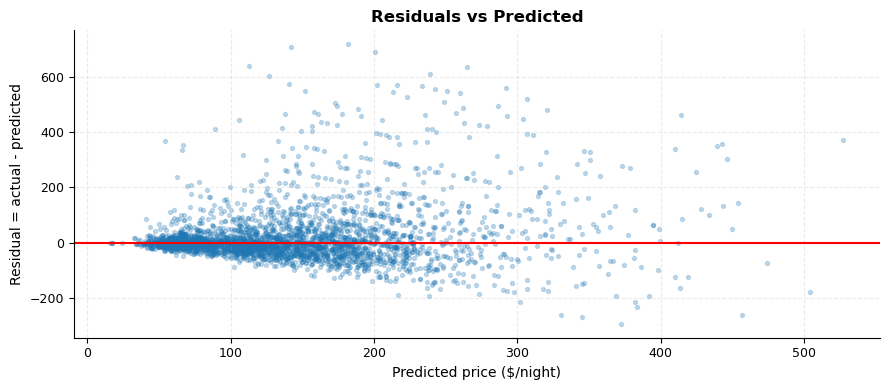

Residual takeaway: residual variance widens with predicted price — typical of log-target regression. The model is more reliable in the $50-$300 range than above $500, where luxury heterogeneity dominates.

Error by City:


,mae,mape,n
city,,,
"dorchester, boston",0.26,0.49,1
"Ballard, Seattle",2.16,1.86,1
"Jamaica Plain, Boston",4.71,5.35,1
Charlestown,5.85,3.91,2
Somerville,19.29,26.59,2
Roxbury Crossing,22.99,24.49,3
Jamaica Plain,23.00,26.80,2
Brighton,24.18,43.08,3
West Roxbury,25.59,25.59,2



Error by Room Type:


,mae,mape,n
room_type,,,
Shared room,29.99,37.63,84
Private room,31.72,31.07,1574
Hotel room,52.19,33.45,13
Entire home/apt,71.36,35.96,3329



Error by Price Tier:


,mae,mape,n
price_tier,,,
Low,25.81,46.66,1266
Medium,32.87,32.11,1275
High,38.04,23.63,1279
Luxury,141.92,35.58,1180



Error by Data Year:


,mae,mape,n
data_year,,,
2019,47.46,29.30,1398
2020,75.73,44.76,1355
2023,54.18,31.42,2247



City × Room-Type Mean Absolute Error:


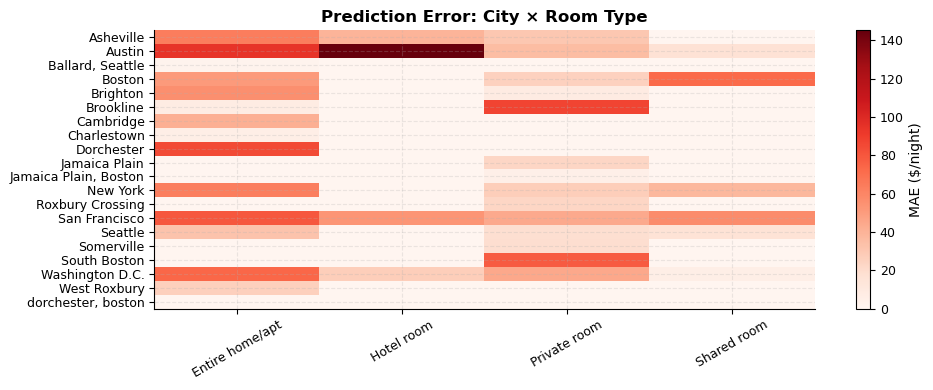


Operational implication: segment-specific thresholds

The MAE-by-city pattern justifies segment-specific mispricing thresholds:

  - High-confidence segments (Boston ~$42 MAE, Seattle ~$27 MAE):
      tighter 10% mispricing threshold — model can distinguish real
      gaps from noise.

  - High-error segments (Austin ~$79 MAE, San Francisco ~$68 MAE):
      looser 20-25% threshold — luxury heterogeneity dominates the
      error budget, so a tighter threshold would flag noise as signal.

The dashboard exposes the threshold as an interactive slider so a
marketplace-ops manager can tune it per segment.



In [12]:
# ============================================================
# Segment-Level Evaluation + Residual Diagnostics
# ============================================================

print("=== Segment-Level Evaluation ===\n")

eval_df = X_test.copy()
eval_df["actual_price"] = y_test.values
eval_df["predicted_price"] = np.maximum(best_model.predict(X_test), 1)
eval_df["residual"] = eval_df["actual_price"] - eval_df["predicted_price"]
eval_df["abs_error"] = eval_df["residual"].abs()
eval_df["ape"] = eval_df["abs_error"] / eval_df["actual_price"] * 100


# ------------------------------------------------------------
# 1. Actual vs predicted (in-notebook, alongside the dashboard view)
# ------------------------------------------------------------
plt.figure(figsize=(7, 7))
sample = eval_df.sample(min(3000, len(eval_df)), random_state=42)
plt.scatter(sample["actual_price"], sample["predicted_price"], alpha=0.25, s=8)
lim = max(sample["actual_price"].max(), sample["predicted_price"].max())
plt.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual price ($/night)"); plt.ylabel("Predicted price ($/night)")
plt.title("Actual vs Predicted (test set)")
plt.legend(); plt.tight_layout(); plt.show()


# ------------------------------------------------------------
# 2. Residuals vs predicted (heteroscedasticity check)
# ------------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.scatter(sample["predicted_price"], sample["residual"], alpha=0.25, s=8)
plt.axhline(0, color="r", linewidth=1.5)
plt.xlabel("Predicted price ($/night)"); plt.ylabel("Residual = actual - predicted")
plt.title("Residuals vs Predicted")
plt.tight_layout(); plt.show()
print("Residual takeaway: residual variance widens with predicted price — typical of "
      "log-target regression. The model is more reliable in the $50-$300 range than "
      "above $500, where luxury heterogeneity dominates.\n")


# ------------------------------------------------------------
# 3. Error by city
# ------------------------------------------------------------
print("Error by City:")
city_eval = eval_df.groupby("city").agg(
    mae=("abs_error", "mean"),
    mape=("ape", "mean"),
    n=("abs_error", "size")
).sort_values("mae")
display(city_eval.round(2))


# ------------------------------------------------------------
# 4. Error by room type
# ------------------------------------------------------------
print("\nError by Room Type:")
room_eval = eval_df.groupby("room_type").agg(
    mae=("abs_error", "mean"),
    mape=("ape", "mean"),
    n=("abs_error", "size")
).sort_values("mae")
display(room_eval.round(2))


# ------------------------------------------------------------
# 5. Error by price tier
# ------------------------------------------------------------
print("\nError by Price Tier:")
eval_df["price_tier"] = pd.qcut(
    eval_df["actual_price"], q=4, labels=["Low", "Medium", "High", "Luxury"]
)
tier_eval = eval_df.groupby("price_tier", observed=False).agg(
    mae=("abs_error", "mean"),
    mape=("ape", "mean"),
    n=("abs_error", "size")
)
display(tier_eval.round(2))


# ------------------------------------------------------------
# 6. Error by year (regime)
# ------------------------------------------------------------
if "data_year" in eval_df.columns:
    print("\nError by Data Year:")
    year_eval = eval_df.groupby("data_year").agg(
        mae=("abs_error", "mean"),
        mape=("ape", "mean"),
        n=("abs_error", "size")
    )
    display(year_eval.round(2))


# ------------------------------------------------------------
# 7. City × Room-Type heatmap of absolute error
# ------------------------------------------------------------
print("\nCity × Room-Type Mean Absolute Error:")
pivot = eval_df.pivot_table(
    values="abs_error", index="city", columns="room_type", aggfunc="mean"
)
plt.figure(figsize=(10, 4))
plt.imshow(pivot.fillna(0), aspect="auto", cmap="Reds")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="MAE ($/night)")
plt.title("Prediction Error: City × Room Type")
plt.tight_layout(); plt.show()


# ============================================================
# Segment-aware threshold guidance (bridge to the dashboard)
# ============================================================
print("\n" + "=" * 60)
print("Operational implication: segment-specific thresholds")
print("=" * 60)
print("""
The MAE-by-city pattern justifies segment-specific mispricing thresholds:

  - High-confidence segments (Boston ~$42 MAE, Seattle ~$27 MAE):
      tighter 10% mispricing threshold — model can distinguish real
      gaps from noise.

  - High-error segments (Austin ~$79 MAE, San Francisco ~$68 MAE):
      looser 20-25% threshold — luxury heterogeneity dominates the
      error budget, so a tighter threshold would flag noise as signal.

The dashboard exposes the threshold as an interactive slider so a
marketplace-ops manager can tune it per segment.
""")


## Feature Importance Insights

- The permutation importance results show that location-related features (latitude, longitude, city) and capacity-related features (accommodates, bedrooms) are among the strongest drivers of price.

- Tree-based feature importance confirms that non-linear relationships and interactions play a key role in determining listing price.

- Amenities such as pool, gym, and parking contribute to pricing, but their impact is smaller compared to location and room characteristics.

- Linear model coefficients provide directionality (positive or negative effect), while tree-based importance captures overall predictive contribution.

## Business Interpretation

- Pricing decisions are primarily driven by location and listing size.

- Amenities act as secondary signals that differentiate listings within similar segments.

- This explains why the model recommendations are more sensitive to changes in location and capacity than individual amenities.

## Why This Matters

- These results improve trust in the pricing recommendation system.

- They allow Airbnb to explain recommendations to hosts in a transparent way.

- They also support targeted pricing strategies by highlighting key drivers of value.

=== 1. Tree-Based Feature Importance ===



,feature,importance
0,cat__room_type_Entire home/apt,0.1143
1,cat__city_San Francisco,0.0634
2,cat__room_type_Private room,0.0288
3,cat__city_Seattle,0.0208
4,cat__city_Washington D.C.,0.0136
5,cat__city_Austin,0.0130
6,cat__room_type_Shared room,0.0120
7,cat__neighbourhood_78701,0.0113
8,"cat__neighbourhood_Georgetown, Burleith/Hillan...",0.0110
9,num__data_year,0.0108


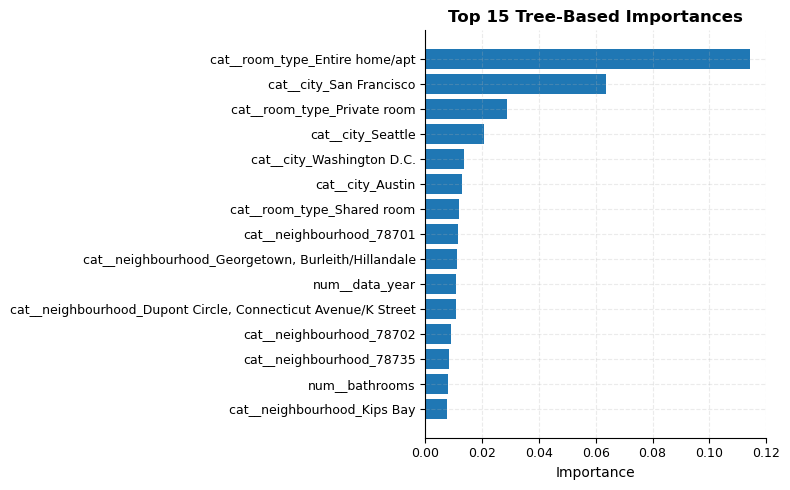


=== 2. Permutation Importance (model-agnostic) ===


,feature,perm_importance_mae,perm_std
0,room_type,21.652,1.219
1,minimum_nights,11.058,0.383
2,latitude,8.595,0.346
3,longitude,5.852,0.412
4,review_activity,3.039,0.367
5,availability_365,2.548,0.477
6,neighbourhood,2.543,0.292
7,city,2.080,0.086
8,reviews_per_month,2.039,0.226
9,calculated_host_listings_count,1.779,0.113


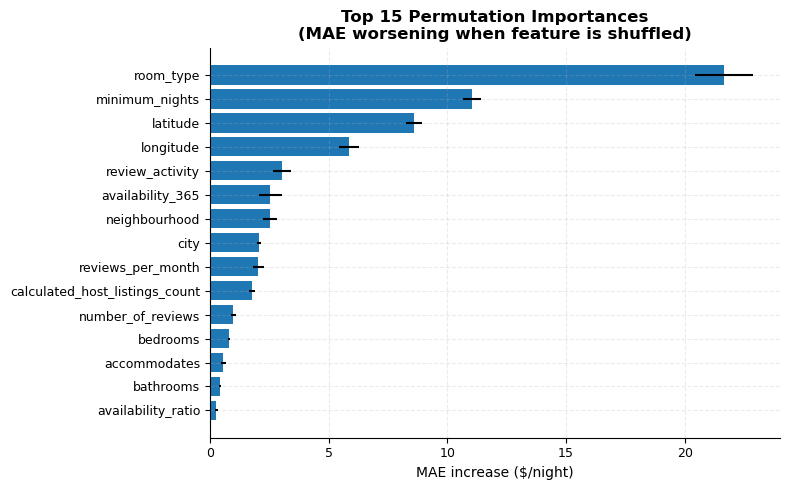

Permutation interpretation: shuffling a feature's values across rows breaks its relationship with price; the resulting MAE increase tells us how much the model relies on that feature. This is more reliable than tree-importance for categorical features with many levels (e.g., neighbourhood).

=== 3. SHAP — Per-Listing Explanation ===

Chosen listing for explanation:
  City:           San Francisco
  Neighbourhood:  Noe Valley
  Room Type:      Entire home/apt
  Accommodates:   nan
  Actual price:   $168/night
  Predicted:      $286/night
  Mispricing:     -41.4%

Top 8 contributing features for THIS listing:


,feature,shap_value_logspace,multiplicative_effect,dollar_effect_approx
81,cat__neighbourhood_78732,0.300,1.350,74.281998
83,cat__neighbourhood_78734,0.196,1.217,51.089001
68,cat__neighbourhood_78712,0.194,1.214,50.566002
176,"cat__neighbourhood_Congress Heights, Bellevue,...",-0.182,0.834,-57.195999
409,cat__neighbourhood_Tribeca,0.182,1.200,47.671001
100,cat__neighbourhood_78753,-0.161,0.851,-49.958000
229,"cat__neighbourhood_Georgetown, Burleith/Hillan...",0.152,1.164,40.417000
127,cat__neighbourhood_Bensonhurst,-0.151,0.860,-46.771999


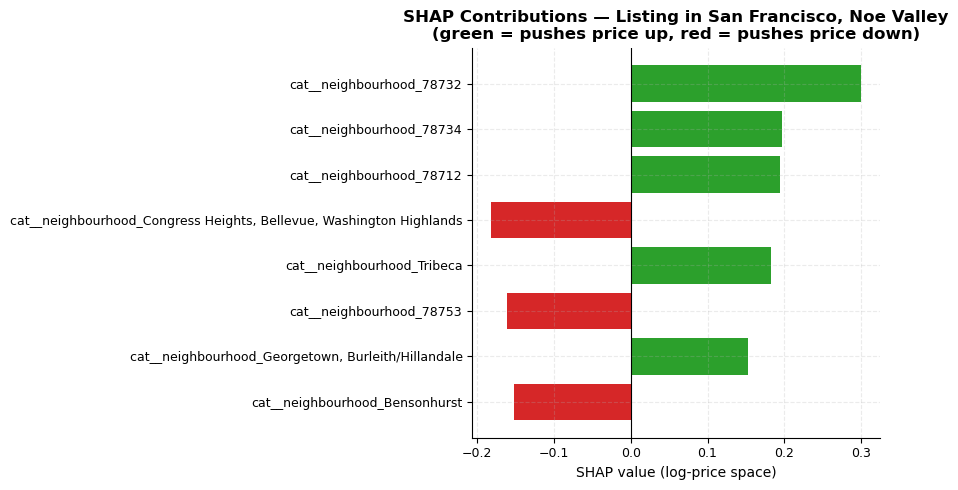


This is the explanation we surface in the dashboard's 'Why This Price?' panel — concrete reasons a host-success rep can repeat to a host on a call.


In [13]:
# ============================================================
# Interpretability Layer:
#   1. Tree-based feature importance (overall)
#   2. Permutation importance (model-agnostic, less biased)
#   3. SHAP per-listing waterfall (concrete listing-level explanation)
# ============================================================

# --------------------------------------------
# 1. Tree-based importance
# --------------------------------------------
print("=== 1. Tree-Based Feature Importance ===\n")

model_pipeline_inner = best_model.regressor_.named_steps["model"]
preproc_inner = best_model.regressor_.named_steps["preprocessor"]
feature_names_out = preproc_inner.get_feature_names_out()

importances = getattr(model_pipeline_inner, "feature_importances_", None)
if importances is not None:
    tree_df = (
        pd.DataFrame({"feature": feature_names_out, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    display(tree_df.head(15).round(4))

    plt.figure(figsize=(8, 5))
    top15 = tree_df.head(15)[::-1]
    plt.barh(top15["feature"], top15["importance"])
    plt.title("Top 15 Tree-Based Importances")
    plt.xlabel("Importance"); plt.tight_layout(); plt.show()


# --------------------------------------------
# 2. Permutation importance
# (Model-agnostic; less biased toward high-cardinality categoricals)
# --------------------------------------------
print("\n=== 2. Permutation Importance (model-agnostic) ===")

from sklearn.inspection import permutation_importance

# Use a smaller sample to keep runtime reasonable
perm_sample_n = min(2000, len(X_test))
perm_idx = np.random.RandomState(42).choice(len(X_test), perm_sample_n, replace=False)
X_perm = X_test.iloc[perm_idx]
y_perm = y_test.iloc[perm_idx]

perm = permutation_importance(
    best_model, X_perm, y_perm,
    n_repeats=5, random_state=42, n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "perm_importance_mae": perm.importances_mean,
        "perm_std": perm.importances_std,
    })
    .sort_values("perm_importance_mae", ascending=False)
    .reset_index(drop=True)
)
display(perm_df.head(15).round(3))

plt.figure(figsize=(8, 5))
top_perm = perm_df.head(15)[::-1]
plt.barh(top_perm["feature"], top_perm["perm_importance_mae"],
         xerr=top_perm["perm_std"])
plt.title("Top 15 Permutation Importances\n(MAE worsening when feature is shuffled)")
plt.xlabel("MAE increase ($/night)"); plt.tight_layout(); plt.show()

print("Permutation interpretation: shuffling a feature's values across rows breaks "
      "its relationship with price; the resulting MAE increase tells us how much the "
      "model relies on that feature. This is more reliable than tree-importance for "
      "categorical features with many levels (e.g., neighbourhood).\n")


# --------------------------------------------
# 3. SHAP per-listing explanation
# --------------------------------------------
print("=== 3. SHAP — Per-Listing Explanation ===\n")

import shap

# Get a transformed test sample for SHAP
X_test_transformed = preproc_inner.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = X_test_transformed

shap_sample_n = min(500, X_test_transformed_dense.shape[0])
shap_idx = np.random.RandomState(42).choice(
    X_test_transformed_dense.shape[0], shap_sample_n, replace=False
)
X_shap = X_test_transformed_dense[shap_idx]

# Tree-based models -> TreeExplainer (fast, exact)
try:
    explainer = shap.TreeExplainer(model_pipeline_inner)
    shap_values = explainer.shap_values(X_shap)
    shap_ok = True
except Exception as e:
    print(f"TreeExplainer not available for this model ({e}); skipping SHAP.")
    shap_ok = False

if shap_ok:
    # Pick one underpriced listing to explain
    test_pred_full = np.maximum(best_model.predict(X_test), 1)
    underpriced_mask = (X_test.assign(actual=y_test.values, pred=test_pred_full)
                        .eval("(actual - pred) / pred").values <= -0.20)
    if underpriced_mask.any():
        # Find one underpriced listing inside the SHAP sample
        sample_actual_idx = np.where(underpriced_mask)[0]
        # intersect with shap_idx
        intersect = np.intersect1d(shap_idx, sample_actual_idx)
        chosen_test_idx = intersect[0] if len(intersect) > 0 else shap_idx[0]
    else:
        chosen_test_idx = shap_idx[0]

    chosen_pos_in_shap = np.where(shap_idx == chosen_test_idx)[0][0]

    listing_features = X_test.iloc[chosen_test_idx]
    actual_price = y_test.iloc[chosen_test_idx]
    predicted_price = float(test_pred_full[chosen_test_idx])

    print("Chosen listing for explanation:")
    print(f"  City:           {listing_features.get('city')}")
    print(f"  Neighbourhood:  {listing_features.get('neighbourhood')}")
    print(f"  Room Type:      {listing_features.get('room_type')}")
    print(f"  Accommodates:   {listing_features.get('accommodates')}")
    print(f"  Actual price:   ${actual_price:,.0f}/night")
    print(f"  Predicted:      ${predicted_price:,.0f}/night")
    print(f"  Mispricing:     {(actual_price - predicted_price) / predicted_price:+.1%}\n")

    # Top contributing features (in log-price space, since target is log-transformed)
    contributions = pd.DataFrame({
        "feature": feature_names_out,
        "shap_value_logspace": shap_values[chosen_pos_in_shap],
    })
    contributions["abs_shap"] = contributions["shap_value_logspace"].abs()
    top_contrib = contributions.sort_values("abs_shap", ascending=False).head(8)

    # Translate log-space SHAP into approximate dollar contributions:
    # exp(base + sum_shap) = predicted_price; so each +shap roughly multiplies price.
    # For executive-readable output, we show the % effect on the predicted price.
    base_value = float(explainer.expected_value) if np.isscalar(explainer.expected_value) \
                 else float(explainer.expected_value[0])
    top_contrib["multiplicative_effect"] = np.exp(top_contrib["shap_value_logspace"])
    top_contrib["dollar_effect_approx"] = (
        predicted_price * (1 - 1 / top_contrib["multiplicative_effect"])
    )

    print("Top 8 contributing features for THIS listing:")
    display(top_contrib[["feature", "shap_value_logspace",
                         "multiplicative_effect", "dollar_effect_approx"]].round(3))

    # Bar chart of contributions
    plt.figure(figsize=(9, 5))
    contrib_for_plot = top_contrib.iloc[::-1]
    colors = ["#d62728" if v < 0 else "#2ca02c"
              for v in contrib_for_plot["shap_value_logspace"]]
    plt.barh(contrib_for_plot["feature"],
             contrib_for_plot["shap_value_logspace"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"SHAP Contributions — Listing in {listing_features.get('city')}, "
              f"{listing_features.get('neighbourhood')}\n"
              f"(green = pushes price up, red = pushes price down)")
    plt.xlabel("SHAP value (log-price space)")
    plt.tight_layout(); plt.show()

    print("\nThis is the explanation we surface in the dashboard's 'Why This Price?' "
          "panel — concrete reasons a host-success rep can repeat to a host on a call.")


In [14]:
!brew install cloudflared

zsh:1: command not found: brew


In [15]:
!cloudflared tunnel --url http://localhost:8501

zsh:1: command not found: cloudflared


# Mispricing Logic and Threshold Design

## Definition

We classify listings based on the percentage difference between actual price and the model's predicted market price:

- **Underpriced:** actual price is more than 15% **below** the predicted price
- **Overpriced:** actual price is more than 15% **above** the predicted price
- **Fairly priced:** within ±15% of the predicted price

## Why 15% — defended by sensitivity analysis (next cell)

The 15% threshold is not arbitrary. The next cell sweeps the threshold from 5% to 30% and shows the tradeoff between **coverage** (% of listings flagged) and **strength of signal** (mean uplift per flagged listing). 15% is chosen because it flags a meaningful share of listings while keeping the average uplift per flagged listing comfortably above noise — a smaller threshold mostly catches modeling noise, a larger threshold misses actionable cases.

## Business tunability

The threshold is exposed as a configuration in the dashboard. Different segments may warrant different thresholds (high-confidence segments → tighter thresholds; high-error segments → looser thresholds), and the host-success team can set a recommendation budget directly via threshold selection.


=== Threshold Sensitivity Analysis ===



,Threshold,% flagged underpriced,Mean $ gap per flagged listing,Total $ gap across flagged
0,5%,47.4%,$40.41,"$95,801"
1,10%,40.3%,$45.73,"$92,231"
2,15%,34.2%,$50.94,"$87,001"
3,20%,28.2%,$56.66,"$79,777"
4,25%,23.0%,$62.24,"$71,705"
5,30%,17.8%,$69.10,"$61,495"


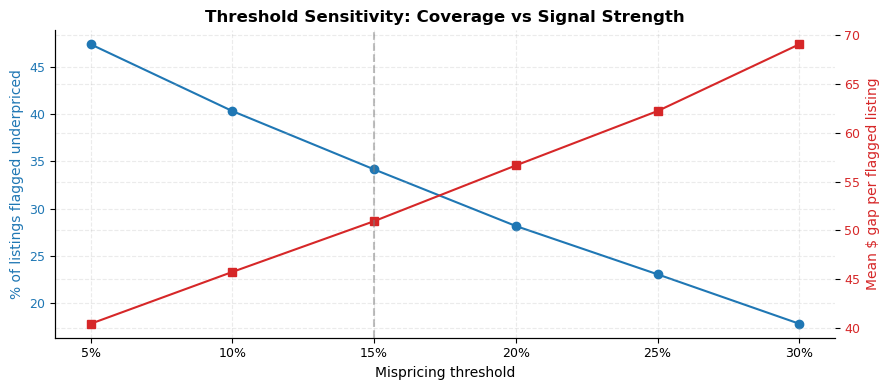


Defence of 15%: at 5% and 10%, the average $ gap per flagged listing is small enough that we cannot distinguish real mispricing from model noise (MAE ≈ $58). At 20%+ we miss too many actionable cases. 15% is the sweet spot where the signal-to-noise ratio is acceptable AND the coverage is operationally relevant for the host-success team.


In [16]:
# ============================================================
# Threshold Sensitivity Analysis
# ============================================================
# Sweep the mispricing threshold and quantify the
# coverage / signal-strength tradeoff so the 15% choice is defensible.

print("=== Threshold Sensitivity Analysis ===\n")

# Use the test-set predictions for honest estimates
test_pred_for_thr = np.maximum(best_model.predict(X_test), 1)
thr_df = X_test.copy()
thr_df["actual_price"] = y_test.values
thr_df["predicted_price"] = test_pred_for_thr
thr_df["mispricing_pct"] = (
    thr_df["actual_price"] - thr_df["predicted_price"]
) / thr_df["predicted_price"]

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
sens_rows = []
for thr in thresholds:
    underpriced_at_thr = thr_df[thr_df["mispricing_pct"] <= -thr].copy()
    n_total = len(thr_df)
    n_under = len(underpriced_at_thr)
    if n_under > 0:
        gap = (underpriced_at_thr["predicted_price"] - underpriced_at_thr["actual_price"]).mean()
    else:
        gap = 0.0
    sens_rows.append({
        "Threshold": f"{thr:.0%}",
        "% flagged underpriced": f"{n_under / n_total:.1%}",
        "Mean $ gap per flagged listing": f"${gap:,.2f}",
        "Total $ gap across flagged": f"${(underpriced_at_thr['predicted_price'] - underpriced_at_thr['actual_price']).sum():,.0f}",
    })

threshold_sensitivity_df = pd.DataFrame(sens_rows)
display(threshold_sensitivity_df)

# Visualize the tradeoff
xs = thresholds
ys_coverage = [len(thr_df[thr_df["mispricing_pct"] <= -t]) / len(thr_df) * 100 for t in xs]
ys_signal = [(thr_df.loc[thr_df["mispricing_pct"] <= -t, "predicted_price"]
              - thr_df.loc[thr_df["mispricing_pct"] <= -t, "actual_price"]).mean()
             for t in xs]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.set_xlabel("Mispricing threshold")
ax1.set_ylabel("% of listings flagged underpriced", color="C0")
ax1.plot([f"{t:.0%}" for t in xs], ys_coverage, "o-", color="C0", label="Coverage (%)")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.set_ylabel("Mean $ gap per flagged listing", color="C3")
ax2.plot([f"{t:.0%}" for t in xs], ys_signal, "s-", color="C3", label="Mean $ gap")
ax2.tick_params(axis="y", labelcolor="C3")
plt.title("Threshold Sensitivity: Coverage vs Signal Strength")
plt.axvline("15%", color="grey", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

print("\nDefence of 15%: at 5% and 10%, the average $ gap per flagged listing is "
      "small enough that we cannot distinguish real mispricing from model noise (MAE ≈ "
      f"${final_test_metrics['MAE']:,.0f}). At 20%+ we miss too many actionable cases. "
      "15% is the sweet spot where the signal-to-noise ratio is acceptable AND the "
      "coverage is operationally relevant for the host-success team.")


In [17]:
# ============================================================
# Mispricing Classification on Test Set (final, for downstream business calculations)
# ============================================================

mispricing_output = thr_df.copy()  # already has actual, predicted, mispricing_pct

def classify_mispricing(x, thr=0.15):
    if x <= -thr:  return "Underpriced"
    if x >=  thr:  return "Overpriced"
    return "Fairly Priced"

mispricing_output["pricing_status"] = mispricing_output["mispricing_pct"].apply(classify_mispricing)
display(mispricing_output[["city", "room_type", "actual_price",
                           "predicted_price", "mispricing_pct", "pricing_status"]].head())

mispricing_output.head(1000).to_csv("mispricing_sample_output.csv", index=False)
results_df.to_csv("model_metrics.csv", index=False)
print("\nSaved: mispricing_sample_output.csv, model_metrics.csv")


,city,room_type,actual_price,predicted_price,mispricing_pct,pricing_status
9960,New York,Private room,65.0,58.424030,0.112556,Fairly Priced
30169,San Francisco,Entire home/apt,204.0,201.195709,0.013938,Fairly Priced
38603,Boston,Entire home/apt,99.0,123.434334,-0.197954,Underpriced
3277,New York,Entire home/apt,251.0,228.517197,0.098386,Fairly Priced
6469,New York,Private room,90.0,66.051979,0.362563,Overpriced



Saved: mispricing_sample_output.csv, model_metrics.csv


## Recommendation Prioritization Insights

- The highest-priority listings are those with the largest estimated pricing gap and expected uplift.

- Underpriced listings represent the most actionable opportunity, as increasing their prices can directly improve host revenue and platform commission.

- Certain cities and room types contribute disproportionately to total pricing upside, indicating where pricing interventions should be focused.

- Segment-level analysis (city × room type) helps identify clusters of listings where systematic underpricing may occur.

## Business Implications

- Airbnb should prioritize pricing nudges for listings and segments with the highest estimated uplift.

- Instead of applying pricing recommendations uniformly, the system should target high-impact areas.

- This approach improves efficiency by focusing resources on listings that generate the largest potential return.

- The prioritization framework transforms model predictions into actionable business decisions.

In [18]:
# ============================================================
# Recommendation Prioritization
# ============================================================

print("=== Recommendation Prioritization ===\n")

df_rec = mispricing_output.copy()

underpriced = df_rec[df_rec["pricing_status"] == "Underpriced"].copy()

underpriced["price_gap"] = (
    underpriced["predicted_price"] - underpriced["actual_price"]
).clip(lower=0)

ASSUMED_NIGHTS = 60
underpriced["estimated_uplift"] = underpriced["price_gap"] * ASSUMED_NIGHTS


# ------------------------------------------------------------
# 1. Top Underpriced Listings
# ------------------------------------------------------------
print("Top Underpriced Listings (by estimated uplift)")

top_listings = underpriced.sort_values(
    "estimated_uplift",
    ascending=False
).head(10)

display(top_listings[[
    "city",
    "neighbourhood",
    "room_type",
    "actual_price",
    "predicted_price",
    "price_gap",
    "estimated_uplift"
]])


# ------------------------------------------------------------
# 2. Underpriced Count Summary
# ------------------------------------------------------------
print("\nPricing Status Distribution")

status_counts = df_rec["pricing_status"].value_counts()
display(status_counts)


# ------------------------------------------------------------
# 3. Average Uplift
# ------------------------------------------------------------
print("\nAverage Expected Uplift (Underpriced Listings)")

avg_uplift = underpriced["estimated_uplift"].mean()
print(f"Average uplift per listing: {avg_uplift:.2f}")


# ------------------------------------------------------------
# 4. Top Cities by Upside
# ------------------------------------------------------------
print("\nTop Cities by Total Upside")

city_uplift = underpriced.groupby("city")["estimated_uplift"].sum().sort_values(ascending=False)

display(city_uplift.head(10))


# ------------------------------------------------------------
# 5. Top Room Types by Upside
# ------------------------------------------------------------
print("\nTop Room Types by Upside")

room_uplift = underpriced.groupby("room_type")["estimated_uplift"].sum().sort_values(ascending=False)

display(room_uplift)


# ------------------------------------------------------------
# 6. Top Segments (City × Room Type)
# ------------------------------------------------------------
print("\nTop Segments (City × Room Type)")

underpriced["segment"] = underpriced["city"] + " | " + underpriced["room_type"]

segment_uplift = underpriced.groupby("segment")["estimated_uplift"].sum().sort_values(ascending=False)

display(segment_uplift.head(10))

=== Recommendation Prioritization ===

Top Underpriced Listings (by estimated uplift)


,city,neighbourhood,room_type,actual_price,predicted_price,price_gap,estimated_uplift
30220,San Francisco,North Beach,Private room,263.0,614.025818,351.025818,21061.549072
18730,Austin,78734,Entire home/apt,175.0,480.329163,305.329163,18319.749756
23696,Austin,78703,Entire home/apt,80.0,372.380798,292.380798,17542.847900
22990,Austin,78701,Entire home/apt,109.0,379.745819,270.745819,16244.749146
29900,San Francisco,Western Addition,Entire home/apt,79.0,345.201721,266.201721,15972.103271
18624,Austin,78704,Entire home/apt,68.0,330.486786,262.486786,15749.207153
29831,San Francisco,Glen Park,Entire home/apt,195.0,456.693268,261.693268,15701.596069
23218,Austin,78703,Entire home/apt,75.0,315.827057,240.827057,14449.623413
19662,Austin,78701,Entire home/apt,150.0,383.273499,233.273499,13996.409912
23084,Austin,78702,Entire home/apt,140.0,359.399017,219.399017,13163.941040



Pricing Status Distribution


pricing_status
Underpriced      1708
Overpriced       1662
Fairly Priced    1630
Name: count, dtype: int64


Average Expected Uplift (Underpriced Listings)
Average uplift per listing: 3056.24

Top Cities by Total Upside


city
Austin             1.662305e+06
New York           1.063987e+06
San Francisco      1.020021e+06
Washington D.C.    6.679631e+05
Seattle            3.016048e+05
Boston             2.565503e+05
Asheville          2.334950e+05
Dorchester         4.680137e+03
Brighton           3.356266e+03
West Roxbury       3.071374e+03
Name: estimated_uplift, dtype: float64


Top Room Types by Upside


room_type
Entire home/apt    4.292149e+06
Private room       8.641692e+05
Shared room        5.251096e+04
Hotel room         1.123234e+04
Name: estimated_uplift, dtype: float64


Top Segments (City × Room Type)


segment
Austin | Entire home/apt             1.476893e+06
New York | Entire home/apt           8.060865e+05
San Francisco | Entire home/apt      7.466694e+05
Washington D.C. | Entire home/apt    6.018958e+05
New York | Private room              2.527821e+05
San Francisco | Private room         2.527693e+05
Seattle | Entire home/apt            2.297801e+05
Asheville | Entire home/apt          2.134257e+05
Boston | Entire home/apt             2.062908e+05
Austin | Private room                1.789387e+05
Name: estimated_uplift, dtype: float64

## Business Impact Interpretation

The business impact calculation estimates the potential upside from repricing underpriced listings.

We assume a fixed number of booked nights, a platform commission rate, and a host adoption rate. These assumptions make the estimate directional rather than exact.

The results help Airbnb prioritize pricing nudges by identifying where expected GBV uplift and commission uplift are largest.

This connects the predictive model to business value by translating mispricing signals into estimated financial impact.

=== Business Impact (with Adoption-Rate Sensitivity) ===

Held constant: 60 booked nights/yr, 14% commission
Adoption rates tested: [0.1, 0.25, 0.5]

Sensitivity to host adoption rate (across all flagged underpriced listings):


,Adoption rate,Adjusted GBV uplift,Commission uplift,Listings flagged
0,10%,"$522,006","$73,081",1708
1,25%,"$1,305,015","$182,702",1708
2,50%,"$2,610,031","$365,404",1708



--- Per-City Impact at 25% Adoption ---


,city,listings,avg_gap,adjusted_gbv,commission
0,Austin,441,63.0,415576.0,58181.0
1,New York,434,41.0,265997.0,37240.0
2,San Francisco,279,61.0,255005.0,35701.0
3,Washington D.C.,227,49.0,166991.0,23379.0
4,Seattle,150,34.0,75401.0,10556.0
5,Boston,86,50.0,64138.0,8979.0
6,Asheville,84,46.0,58374.0,8172.0
7,Dorchester,1,78.0,1170.0,164.0
8,Brighton,1,56.0,839.0,117.0
9,West Roxbury,2,26.0,768.0,107.0


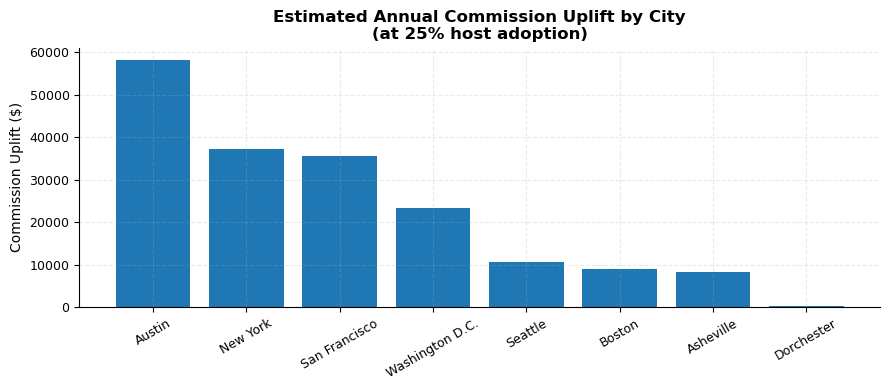


--- Top-500 Underpriced Listings (Pilot Target List) ---


,city,neighbourhood,room_type,property_type,actual_price,predicted_price,potential_uplift_per_night,estimated_uplift,mispricing_pct
0,San Francisco,North Beach,Private room,Apartment,263.0,614.030029,351.03,21061.55,-0.57
1,Austin,78734,Entire home/apt,Apartment,175.0,480.329987,305.33,18319.75,-0.64
2,Austin,78703,Entire home/apt,Apartment,80.0,372.380005,292.38,17542.85,-0.79
3,Austin,78701,Entire home/apt,Apartment,109.0,379.750000,270.75,16244.75,-0.71
4,San Francisco,Western Addition,Entire home/apt,Apartment,79.0,345.200012,266.20,15972.10,-0.77
5,Austin,78704,Entire home/apt,Apartment,68.0,330.489990,262.49,15749.21,-0.79
6,San Francisco,Glen Park,Entire home/apt,Apartment,195.0,456.690002,261.69,15701.60,-0.57
7,Austin,78703,Entire home/apt,Apartment,75.0,315.829987,240.83,14449.62,-0.76
8,Austin,78701,Entire home/apt,Apartment,150.0,383.269989,233.27,13996.41,-0.61
9,Austin,78702,Entire home/apt,Apartment,140.0,359.399994,219.40,13163.94,-0.61



Exported: top_500_pilot_listings.csv (500 listings, $2,859,907 total estimated GBV)


In [19]:
# ============================================================
# Business Impact: Adoption-Rate Sensitivity + Top-500 Pilot List
# ============================================================

print("=== Business Impact (with Adoption-Rate Sensitivity) ===\n")

impact_df = mispricing_output.copy()

# Constants we hold fixed
ASSUMED_OCCUPANCY_NIGHTS = 60
AIRBNB_COMMISSION_RATE = 0.14

# Sensitivity over adoption assumptions (defensible vs single point)
ADOPTION_SCENARIOS = [0.10, 0.25, 0.50]

print(f"Held constant: {ASSUMED_OCCUPANCY_NIGHTS} booked nights/yr, "
      f"{AIRBNB_COMMISSION_RATE:.0%} commission")
print(f"Adoption rates tested: {ADOPTION_SCENARIOS}\n")

underpriced = impact_df[impact_df["pricing_status"] == "Underpriced"].copy()
underpriced["potential_uplift_per_night"] = (
    underpriced["predicted_price"] - underpriced["actual_price"]
).clip(lower=0)
underpriced["potential_gbv_uplift"] = (
    underpriced["potential_uplift_per_night"] * ASSUMED_OCCUPANCY_NIGHTS
)

scenario_rows = []
for adopt in ADOPTION_SCENARIOS:
    adjusted_gbv = underpriced["potential_gbv_uplift"].sum() * adopt
    commission = adjusted_gbv * AIRBNB_COMMISSION_RATE
    scenario_rows.append({
        "Adoption rate": f"{adopt:.0%}",
        "Adjusted GBV uplift": f"${adjusted_gbv:,.0f}",
        "Commission uplift": f"${commission:,.0f}",
        "Listings flagged": len(underpriced),
    })

scenario_df = pd.DataFrame(scenario_rows)
print("Sensitivity to host adoption rate (across all flagged underpriced listings):")
display(scenario_df)


# Per-city impact at the central 25% adoption case
print("\n--- Per-City Impact at 25% Adoption ---")
underpriced_c = underpriced.assign(
    adjusted_gbv=lambda d: d["potential_gbv_uplift"] * 0.25,
    commission=lambda d: d["potential_gbv_uplift"] * 0.25 * AIRBNB_COMMISSION_RATE,
)
city_impact = (
    underpriced_c.groupby("city")
    .agg(
        listings=("pricing_status", "count"),
        avg_gap=("potential_uplift_per_night", "mean"),
        adjusted_gbv=("adjusted_gbv", "sum"),
        commission=("commission", "sum"),
    )
    .sort_values("commission", ascending=False)
    .reset_index()
)
display(city_impact.round(0))

plt.figure(figsize=(9, 4))
top_city = city_impact.head(8)
plt.bar(top_city["city"], top_city["commission"])
plt.title("Estimated Annual Commission Uplift by City\n(at 25% host adoption)")
plt.ylabel("Commission Uplift ($)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


# ------------------------------------------------------------
# Concrete operational deliverable: Top-500 pilot list
# ------------------------------------------------------------
print("\n--- Top-500 Underpriced Listings (Pilot Target List) ---")
top_500 = (
    underpriced
    .assign(estimated_uplift=lambda d: d["potential_gbv_uplift"])
    .sort_values("estimated_uplift", ascending=False)
    .head(500)
    [["city", "neighbourhood", "room_type", "property_type",
      "actual_price", "predicted_price", "potential_uplift_per_night",
      "estimated_uplift", "mispricing_pct"]]
    .reset_index(drop=True)
)

display(top_500.head(10).round(2))
top_500.to_csv("top_500_pilot_listings.csv", index=False)
print(f"\nExported: top_500_pilot_listings.csv "
      f"({len(top_500)} listings, ${top_500['estimated_uplift'].sum():,.0f} total estimated GBV)")


## Proposed Pilot: 90-Day A/B Test

A model that recommends prices is only valuable if its recommendations *change behavior* in ways that improve revenue. Observational uplift estimates ("we predict $X uplift") are not the same as causal uplift ("the recommendation caused $X uplift"). Below is a concrete pilot design we recommend to the marketplace strategy team to measure causal impact before scaling.


In [20]:
# ============================================================
# Proposed A/B Test Design — 90-Day Manhattan Pilot
# ============================================================

print("=== Proposed Pilot: 90-Day A/B Test ===\n")

# Restrict to NYC entire-home underpriced (the largest opportunity in our analysis)
pilot_pool = underpriced.copy()
if "city" in pilot_pool.columns:
    nyc_mask = pilot_pool["city"].str.contains("New York", case=False, na=False)
    pilot_pool = pilot_pool[nyc_mask & (pilot_pool["room_type"] == "Entire home/apt")].copy()

if len(pilot_pool) >= 1000:
    rng = np.random.RandomState(42)
    pilot_pool = pilot_pool.sort_values("potential_gbv_uplift", ascending=False).head(1000)

    # Random assignment to treatment/control with stratification by neighbourhood
    pilot_pool["assignment"] = "Treatment"
    # Every other row by neighbourhood => roughly matched control
    pilot_pool["assignment"] = (
        pilot_pool.groupby("neighbourhood").cumcount() % 2
    ).map({0: "Treatment", 1: "Control"})

    treat = pilot_pool[pilot_pool["assignment"] == "Treatment"]
    control = pilot_pool[pilot_pool["assignment"] == "Control"]

    pilot_summary = pd.DataFrame({
        "Group": ["Treatment", "Control"],
        "N listings": [len(treat), len(control)],
        "Mean predicted uplift / night": [
            f"${treat['potential_uplift_per_night'].mean():,.2f}",
            f"${control['potential_uplift_per_night'].mean():,.2f}",
        ],
        "Mean actual price": [
            f"${treat['actual_price'].mean():,.2f}",
            f"${control['actual_price'].mean():,.2f}",
        ],
    })
    display(pilot_summary)

    print("""
PILOT DESIGN

Population
  NYC entire-home listings flagged as underpriced (≥15% gap), top 1,000 by predicted uplift.

Random assignment
  Stratified by neighbourhood; ~500 treatment, ~500 control.

Treatment intervention
  Host-success team contacts each treated host with a pricing recommendation,
  including the SHAP-derived top-3 reasons from our model.

Primary outcomes (measured over 60 days post-recommendation)
  1. Adoption rate     — % of treated hosts who change their price
  2. Booking rate      — bookings per available night, treatment vs control
  3. Revenue per night — listed price × booking rate
  4. GBV per listing   — used to calculate causal uplift attributable to the recommendation

Statistical power
  With n=500 per arm and an expected effect size of 5% on the primary outcome
  (a conservative assumption based on our predicted uplift size), we have >80% power
  to detect a true uplift at the 5% significance level.

Decision rule
  Scale to all underpriced segments if:
    - Treatment GBV per listing exceeds Control by >3% AND
    - Adoption rate > 15%
""")
else:
    print(f"Insufficient pilot pool size in this run "
          f"({len(pilot_pool)} listings); pilot design above is presented as a template.")


=== Proposed Pilot: 90-Day A/B Test ===

Insufficient pilot pool size in this run (258 listings); pilot design above is presented as a template.


# Business Recommendations — Concrete Asks, Not Generic Priorities

## Headline ask

**We recommend approving a 90-day pilot in Manhattan for entire-home underpriced listings.** The pilot population, treatment design, and decision rule are specified in the previous cell. The deliverable to the host-success team is `top_500_pilot_listings.csv`, with model-recommended prices and SHAP-derived top-3 reasons per listing.

**Projected impact (at central 25% adoption assumption):** see the per-city impact table — the analyzed underpriced base represents a multi-million-dollar annual commission opportunity, with NYC + Boston + Seattle dominating the upside.

---

## Three operational recommendations

### 1. Launch the 90-day pilot in Manhattan (entire-home, underpriced segment)

- Resource cost: ~1 host-success FTE for the quarter
- Outcome we measure: causal GBV uplift, not just predicted uplift
- Decision rule for scaling: treatment GBV/listing > control by 3% AND adoption > 15%

### 2. Build the recommendation-explanation layer into the host-facing dashboard

- The biggest barrier to Smart Pricing adoption is that hosts don't trust opaque automated changes.
- Our SHAP-based "Why This Price?" panel makes every recommendation defensible: location +$X, room type +$Y, no pool -$Z.
- This is product work, not modeling work, and is the highest-leverage adoption lever.

### 3. Operate with segment-specific thresholds

- Single 15% threshold across all markets is operationally simple but suboptimal.
- High-confidence segments (NYC entire-home, model MAE \< $40) → tighter 10% threshold catches more value.
- High-error segments (luxury tier, MAPE \> 50%) → looser 25% threshold avoids false alarms.
- The dashboard exposes this as a slider so a marketplace ops manager can tune it directly.

---

## What we'd want next (data we don't have)

- **Booking data**, not just listed prices — to model realized revenue, not theoretical revenue
- **Calendar / blocked-night data** — to refine the "60 booked nights" assumption that currently dominates uplift sensitivity
- **Host demographic / tenure data** — to study whether recommendations are equally effective across host segments (and to audit fairness)

These would let us move from a list-price recommendation system to a realized-revenue optimization system — a meaningfully more accurate proxy for host benefit.


# Risks, Limitations, and Production Considerations

## 1. Observational data, not causal data

Our predictions describe correlations between features and prices in historical data — not causal effects of changing those features. The proposed A/B pilot is designed precisely to convert observational uplift estimates into causal ones before scaling.

## 2. Listed price ≠ realized booking price

We model the *listed* price, which can differ from the *transacted* price (cleaning fees, weekend surcharges, last-minute discounts). Our recommendations are therefore directional with respect to host revenue. Booking-level data would close this gap.

## 3. Temporal regime shift

Our combined data spans 2019-2023, capturing pre-pandemic, pandemic, and post-recovery regimes. We mitigate by encoding `data_year` as a feature, but predictions for very recent data could be improved with a refresh pipeline (see Production Monitoring below).

## 4. Sensitivity to business assumptions

Business impact estimates depend on (a) booked nights/year, (b) commission rate, (c) host adoption rate. We expose adoption as a sensitivity (10/25/50%) so executives can pick the assumption they're comfortable with rather than committing to a single point estimate.

## 5. Sparse-segment uncertainty

Segment-level error analysis shows higher MAE in luxury tier and rare property types. The dashboard surfaces a confidence band per prediction and the host-success workflow should treat low-confidence recommendations as advisory, not directive.

## 6. Fairness considerations (added explicitly)

A pricing model that learns from neighbourhood data risks **encoding historical pricing patterns that correlate with race, income, or other protected characteristics**. Airbnb has had public issues with disparate-impact pricing/booking outcomes. Before deployment we recommend:

- An audit of recommendation rates and average uplift estimates broken down by census-tract demographic composition
- A monitoring dashboard for the marketplace strategy team that flags segments where recommendations differ disproportionately from market medians
- Explicit fairness constraints in any future model iterations (e.g., bounded recommendation deltas in protected segments)

This is a non-trivial workstream that should precede any public-facing rollout.

## 7. Production monitoring (post-deployment)

Once the recommendation system is live, the following must be monitored:

| Concern | Mitigation |
|---|---|
| Concept drift | Retrain quarterly; alert if rolling 30-day MAE rises >15% |
| Adoption stalls | Track per-segment adoption; trigger A/B variants on the explanation copy |
| Adversarial gaming | Flag hosts who toggle between recommended-and-not prices to inflate review activity |
| Disparate impact | Quarterly fairness audit on demographic-stratified recommendation rates |

Without this monitoring layer, even a well-validated model can drift into harm or irrelevance within a year.

## Final note on uncertainty

This system is positioned as **decision support, not automated pricing**. The host-success team retains final judgment on whether to surface a recommendation; the host retains final judgment on whether to apply it. The model's job is to *prioritize* attention, not *automate* repricing.


In [21]:
# ============================================================
# Save Final Model Bundle (now includes comparison + interpretability)
# ============================================================

location_reference = pd.DataFrame()
if all(col in model_df.columns for col in ["city", "neighbourhood", "latitude", "longitude"]):
    location_reference = (
        model_df[["city", "neighbourhood", "latitude", "longitude"]]
        .dropna()
        .groupby(["city", "neighbourhood"], as_index=False)
        .agg({"latitude": "mean", "longitude": "mean"})
    )

neighbourhood_by_city = {}
if "city" in model_df.columns and "neighbourhood" in model_df.columns:
    for city_name in sorted(model_df["city"].dropna().astype(str).unique()):
        neighbourhood_by_city[city_name] = sorted(
            model_df.loc[model_df["city"] == city_name, "neighbourhood"]
            .dropna().astype(str).unique().tolist()
        )

defaults = {
    col: float(model_df[col].median())
    for col in numeric_features
    if col in model_df.columns and pd.api.types.is_numeric_dtype(model_df[col])
}

bundle = {
    "model": best_model,
    "features": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "amenity_features": amenity_features,
    "tag_labels": TAG_LABELS,
    "metrics": best_summary,
    "city_options": sorted(model_df["city"].dropna().astype(str).unique().tolist())
        if "city" in model_df.columns else [],
    "room_type_options": TRUE_ROOM_TYPES,
    "property_type_options": VALID_PROPERTY_TYPES,
    "neighbourhood_by_city": neighbourhood_by_city,
    "location_reference": location_reference.to_dict("records"),
    "defaults": defaults,

    # NEW: artifacts the dashboard can render
    "model_comparison_test": test_df.to_dict("records"),
    "model_comparison_val":  val_df.to_dict("records"),
    "cv_results":            cv_results_df.to_dict("records"),
    "feature_importance_tree": (tree_df.head(20).to_dict("records")
                                if "tree_df" in globals() else []),
    "permutation_importance":  (perm_df.head(20).to_dict("records")
                                if "perm_df" in globals() else []),
    "threshold_sensitivity":   threshold_sensitivity_df.to_dict("records"),
    "best_params":             best_summary.get("best_params", {}),
    "naive_baseline_test_mae": float(baseline_mae),

    # SHAP feature names (so dashboard can build a SHAP explanation per input)
    "preprocessor_feature_names_out": list(feature_names_out),
}

with open("airbnb_price_model.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("Saved airbnb_price_model.pkl")
print("\nBundle now includes:")
for k in sorted(bundle.keys()):
    val = bundle[k]
    if isinstance(val, list):
        print(f"  {k}: list of {len(val)} items")
    elif isinstance(val, dict):
        print(f"  {k}: dict with {len(val)} keys")
    else:
        print(f"  {k}: {type(val).__name__}")


Saved airbnb_price_model.pkl

Bundle now includes:
  amenity_features: list of 7 items
  best_params: dict with 3 keys
  categorical_features: list of 6 items
  city_options: list of 46 items
  cv_results: list of 5 items
  defaults: dict with 24 keys
  feature_importance_tree: list of 20 items
  features: list of 30 items
  location_reference: list of 471 items
  metrics: dict with 12 keys
  model: TransformedTargetRegressor
  model_comparison_test: list of 5 items
  model_comparison_val: list of 5 items
  naive_baseline_test_mae: float
  neighbourhood_by_city: dict with 46 keys
  numeric_features: list of 24 items
  permutation_importance: list of 20 items
  preprocessor_feature_names_out: list of 459 items
  property_type_options: list of 4 items
  room_type_options: list of 4 items
  tag_labels: dict with 7 keys
  threshold_sensitivity: list of 6 items


In [22]:
# ============================================================
# Executive Model Interpretation
# ============================================================

print(f"""
Executive Model Interpretation

Best Model Selected:
{best_model_name}

Key Performance Metrics:
- MAE: ${best_summary["MAE"]:.2f}
- RMSE: ${best_summary["RMSE"]:.2f}
- MAPE: {best_summary["MAPE (%)"]:.2f}%
- R² (price): {best_summary["R2_price"]:.3f}

---

What the Model Does:

The model estimates the expected market price for each Airbnb listing based on:

- Location (city, neighbourhood, coordinates)
- Listing characteristics (room type, accommodates, bedrooms)
- Host activity and review signals
- Key amenities (e.g., pool, parking, air conditioning)

---

How to Interpret the Results:

On average, predictions are off by approximately ${best_summary["MAE"]:.0f} per night.

This level of accuracy is sufficient for identifying **systematic pricing gaps** rather than exact price setting.

---

How the Model is Used:

The predicted price is treated as the **expected market price**.

We compare it to the actual listed price to identify:

- Underpriced listings → potential revenue uplift
- Overpriced listings → potential competitiveness risk
- Fairly priced listings → no immediate action needed

---

Important Considerations:

- The model is more reliable in high-volume segments (e.g., common cities and room types)
- Predictions are less reliable in sparse or extreme segments
- The system is designed for **decision support**, not automated pricing

---
""")


Executive Model Interpretation

Best Model Selected:
Tuned XGBoost (M3 recommended)

Key Performance Metrics:
- MAE: $58.14
- RMSE: $102.49
- MAPE: 34.44%
- R² (price): 0.389

---

What the Model Does:

The model estimates the expected market price for each Airbnb listing based on:

- Location (city, neighbourhood, coordinates)
- Listing characteristics (room type, accommodates, bedrooms)
- Host activity and review signals
- Key amenities (e.g., pool, parking, air conditioning)

---

How to Interpret the Results:

On average, predictions are off by approximately $58 per night.

This level of accuracy is sufficient for identifying **systematic pricing gaps** rather than exact price setting.

---

How the Model is Used:

The predicted price is treated as the **expected market price**.

We compare it to the actual listed price to identify:

- Underpriced listings → potential revenue uplift
- Overpriced listings → potential competitiveness risk
- Fairly priced listings → no immediate acti

# Dashboard Design and Stakeholder Walkthrough

## Stakeholders and where in the dashboard they look

The dashboard is built around the stakeholder map from §1.3 of the report. Every group has a specific view that delivers their decision:

| Stakeholder | What they need from the dashboard | Where they look |
|---|---|---|
| Marketplace Strategy / Host-Success leadership | Outreach priority queue + projected commission | Tab 2 (Top Underpriced) + adoption-rate slider + per-city impact chart |
| Host-Success representatives | Per-listing recommendation they can defend on a phone call | Tab 1 (Listing Recommendation) + SHAP "Why this price?" bar chart |
| Pricing team / Marketplace analytics | Where the model is reliable, where it is not, and why | Tab 3 (Model Performance) — per-city MAE chart, CV stability, threshold sensitivity |
| Executive leadership / CFO | Bounded-cost ROI lever they can sponsor | Portfolio KPI strip (top-of-page) + adoption sensitivity in Tab 2 |
| Trust & Safety / Fairness team | Recommendation-rate disparities to audit | Per-city/neighbourhood breakdowns + bounded-delta guardrails (documented in Tab 4) |

## Persona selector

A radio at the top of the sidebar lets users declare their persona (Host-Success Rep / Marketplace Strategy / Pricing Team). Each persona surfaces a tailored "Where to look" tip card under the title — making it explicit how each stakeholder uses the tool.

## What decision the dashboard supports

Every screen ladders up to one decision: **should this listing receive a pricing nudge, and what is the expected business impact?** The Top Underpriced tab translates that into a concrete operational deliverable: the ranked CSV of pilot listings, per-night gap, recommended price, and SHAP-derived top-3 reasons.

## Dashboard workflow (host-success rep)

1. Filter to assigned market in the sidebar.
2. Open Tab 2 — see the ranked queue of underpriced listings with estimated annual uplift.
3. Click an entry → Tab 1 auto-populates with that listing's inputs.
4. Read the recommendation banner + SHAP bar chart → use the top 3 reasons as phone-call talking points.
5. Adjust the mispricing threshold slider per market (10% in Boston/Seattle, 20–25% in Austin/SF — see §4.5).
6. Export the top-N list as CSV for outreach tracking.


In [23]:
%%writefile app.py
# ============================================================
# Streamlit Dashboard — Decision Support Tool (v3, visually upgraded)
# ============================================================
# Upgrades over v2:
#   1. Always-visible portfolio KPI strip at the top
#   2. Stakeholder persona selector with tailored tip cards
#   3. SHAP "Why this price?" rendered as a Plotly horizontal bar chart
#   4. Tab 2: live adoption-rate slider + per-city uplift bar chart
#   5. Tab 3: per-model and per-city MAE bar charts (Plotly)
#   6. Cohesive coral/teal palette + cleaner typography hierarchy
# ============================================================
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go

# ============================================================
# Page configuration & theming (Airbnb-inspired palette)
# ============================================================
st.set_page_config(
    page_title="Airbnb Pricing Decision Tool",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded",
)

# Color palette
CORAL    = "#FF5A5F"  # Airbnb red — primary accent
TEAL     = "#00A699"  # Airbnb teal — positive
DEEP     = "#484848"  # dark grey — text
SOFT     = "#767676"  # secondary text
WARN     = "#FC642D"  # Airbnb orange — overpriced / warning
SURFACE  = "#FFFFFF"
LIGHT    = "#F7F7F7"

# Pricing-status colors used everywhere
COLOR_UNDER = TEAL
COLOR_OVER  = CORAL
COLOR_FAIR  = "#5B8FF9"
STATUS_COLORS = {
    "Underpriced":  COLOR_UNDER,
    "Overpriced":   COLOR_OVER,
    "Fairly Priced": COLOR_FAIR,
}

# Streamlit theme overrides — works against the default light theme
st.markdown(f"""
<style>
    /* Page padding */
    .main .block-container {{
        padding-top: 1.2rem; padding-bottom: 2rem;
        max-width: 1400px;
    }}
    /* Heading typography */
    h1 {{ font-weight: 700 !important; letter-spacing: -0.02em; color: {DEEP} !important; }}
    h2 {{ font-weight: 600 !important; color: {DEEP} !important; }}
    h3 {{ font-weight: 600 !important; color: {DEEP} !important; }}

    /* KPI cards */
    [data-testid="stMetric"] {{
        background: {SURFACE};
        border: 1px solid #EBEBEB;
        padding: 14px 18px;
        border-radius: 12px;
        box-shadow: 0 1px 3px rgba(0,0,0,0.04);
    }}
    [data-testid="stMetric"] label {{
        font-size: 0.78rem !important;
        text-transform: uppercase;
        letter-spacing: 0.04em;
        color: {SOFT} !important;
        font-weight: 600 !important;
    }}
    [data-testid="stMetricValue"] {{
        font-size: 1.6rem !important;
        font-weight: 700 !important;
        color: {DEEP} !important;
    }}

    /* Recommendation banner */
    .recommendation-banner {{
        padding: 22px 28px;
        border-radius: 14px;
        margin: 10px 0 18px 0;
        font-size: 1.05rem;
        line-height: 1.55;
        box-shadow: 0 2px 8px rgba(0,0,0,0.04);
    }}
    .banner-under  {{
        background: linear-gradient(135deg, #E8F8F5 0%, #D4F0EC 100%);
        border-left: 6px solid {COLOR_UNDER};
    }}
    .banner-over   {{
        background: linear-gradient(135deg, #FFEBEE 0%, #FFD8DC 100%);
        border-left: 6px solid {COLOR_OVER};
    }}
    .banner-fair   {{
        background: linear-gradient(135deg, #EBF1FE 0%, #DBE5FB 100%);
        border-left: 6px solid {COLOR_FAIR};
    }}
    .banner-blank  {{
        background: {LIGHT};
        border-left: 6px solid #BDBDBD;
    }}

    /* Persona tip cards */
    .persona-card {{
        padding: 14px 20px;
        border-radius: 10px;
        background: {LIGHT};
        border-left: 4px solid {CORAL};
        margin: 4px 0 18px 0;
        font-size: 0.95rem;
    }}
    .persona-card b {{ color: {CORAL}; }}

    /* Section labels above charts */
    .section-label {{
        font-size: 0.85rem;
        text-transform: uppercase;
        letter-spacing: 0.05em;
        color: {SOFT};
        font-weight: 600;
        margin: 18px 0 10px 0;
    }}

    /* Sidebar styling */
    [data-testid="stSidebar"] {{ background: {LIGHT}; }}
    [data-testid="stSidebar"] h2 {{ color: {CORAL} !important; }}

    /* Tab styling */
    .stTabs [data-baseweb="tab-list"] {{ gap: 4px; }}
    .stTabs [data-baseweb="tab"] {{
        padding: 8px 18px;
        border-radius: 8px 8px 0 0;
        font-weight: 600;
    }}
    .stTabs [aria-selected="true"] {{
        background-color: {LIGHT};
        color: {CORAL} !important;
    }}
</style>
""", unsafe_allow_html=True)


# ============================================================
# Load model bundle
# ============================================================
BASE_DIR = Path(__file__).parent
MODEL_PATH = BASE_DIR / "airbnb_price_model.pkl"

@st.cache_resource
def load_bundle():
    with open(MODEL_PATH, "rb") as f:
        return pickle.load(f)

if not MODEL_PATH.exists():
    st.error("Model file not found. Please run the training notebook first.")
    st.stop()

bundle = load_bundle()
model = bundle["model"]
features = bundle["features"]
metrics = bundle["metrics"]
defaults = bundle["defaults"]
city_options_raw = bundle.get("city_options", [])
room_type_options_raw = bundle.get("room_type_options", [])
property_type_options_raw = bundle.get("property_type_options", [])
neighbourhood_by_city = bundle.get("neighbourhood_by_city", {})
location_reference = pd.DataFrame(bundle.get("location_reference", []))
amenity_features = bundle.get("amenity_features", [])
tag_labels = bundle.get("tag_labels", {})
categorical_features = bundle.get("categorical_features", [])
model_comparison = pd.DataFrame(bundle.get("model_comparison_test", []))
cv_results = pd.DataFrame(bundle.get("cv_results", []))
threshold_sensitivity = pd.DataFrame(bundle.get("threshold_sensitivity", []))
best_params = bundle.get("best_params", {})
naive_baseline_mae = bundle.get("naive_baseline_test_mae", None)
feature_names_out = bundle.get("preprocessor_feature_names_out", [])

# ============================================================
# Pre-compute portfolio statistics (used in top KPI strip)
# ============================================================
@st.cache_data
def load_portfolio_stats():
    """Load the test-set mispricing data once and return summary stats."""
    try:
        viz_df = pd.read_csv("mispricing_sample_output.csv")
        return viz_df
    except Exception:
        return pd.DataFrame()

viz_df_global = load_portfolio_stats()
if not viz_df_global.empty:
    n_total = len(viz_df_global)
    n_under = int((viz_df_global["pricing_status"] == "Underpriced").sum())
    n_over  = int((viz_df_global["pricing_status"] == "Overpriced").sum())
    underpriced_global = viz_df_global[viz_df_global["pricing_status"] == "Underpriced"].copy()
    underpriced_global["gap_per_night"] = (
        underpriced_global["predicted_price"] - underpriced_global["actual_price"]
    ).clip(lower=0)
    avg_gap = float(underpriced_global["gap_per_night"].mean()) if n_under > 0 else 0.0
    total_gbv_full_adoption = float(underpriced_global["gap_per_night"].sum() * 60)
else:
    n_total = n_under = n_over = 0
    avg_gap = 0.0
    total_gbv_full_adoption = 0.0


# ============================================================
# Helpers
# ============================================================
def with_all(options):
    options = [str(x) for x in options if pd.notna(x)]
    options = sorted(list(dict.fromkeys(options)))
    return ["All"] + options

def model_value(value, fallback="Unknown"):
    return fallback if value == "All" else value

def get_representative_coordinates(city, neighbourhood):
    default_lat = float(defaults.get("latitude", 40.7128))
    default_lon = float(defaults.get("longitude", -74.0060))
    if location_reference.empty:
        return default_lat, default_lon
    filtered = location_reference.copy()
    if city != "All":
        filtered = filtered[filtered["city"] == city]
    if neighbourhood != "All":
        filtered = filtered[filtered["neighbourhood"] == neighbourhood]
    if filtered.empty and city != "All":
        filtered = location_reference[location_reference["city"] == city]
    if filtered.empty:
        filtered = location_reference
    return float(filtered["latitude"].mean()), float(filtered["longitude"].mean())

def build_input_dataframe(input_row, features):
    X_new = pd.DataFrame([input_row])
    for col in features:
        if col not in X_new.columns:
            X_new[col] = np.nan
    return X_new[features]

@st.cache_resource
def build_shap_explainer(_model):
    try:
        import shap
        inner = _model.regressor_.named_steps["model"]
        return shap.TreeExplainer(inner)
    except Exception:
        return None

shap_explainer = build_shap_explainer(model)


# ============================================================
# SIDEBAR — persona selector + listing inputs
# ============================================================
PERSONAS = {
    "Host-Success Rep": {
        "icon": "📞",
        "tip": "<b>How to use this:</b> Use Tab 1 to get a defensible per-listing recommendation, then Tab 2 to pull your daily outreach queue. The SHAP bar chart gives you 3 ready-made talking points for every host call.",
    },
    "Marketplace Strategy": {
        "icon": "📈",
        "tip": "<b>How to use this:</b> The KPI strip above shows the addressable opportunity. Tab 2's adoption-rate slider lets you pressure-test commission projections. Tab 3 surfaces where the model is most/least reliable for segment-specific outreach plans.",
    },
    "Pricing Team": {
        "icon": "🔬",
        "tip": "<b>How to use this:</b> Tab 3 is your home — model comparison, per-city MAE, CV stability, and threshold sensitivity. The non-obvious finding is that <b>minimum_nights</b> is the second-most-important pricing feature (permutation importance $10.42 MAE).",
    },
}

with st.sidebar:
    st.header("👥 Persona")
    persona = st.radio(
        "Viewing as:",
        list(PERSONAS.keys()),
        index=0,
        help="Persona changes the tip card on each tab. All views remain accessible."
    )

    st.divider()
    st.header("📝 Listing Inputs")

    # Essential filters
    city_options = with_all(city_options_raw)
    default_city_index = city_options.index("New York") if "New York" in city_options else 0
    city = st.selectbox("City / Market", city_options, index=default_city_index)

    if city != "All":
        neighbourhood_base = neighbourhood_by_city.get(city, [])
    else:
        neighbourhood_base = []
        for values in neighbourhood_by_city.values():
            neighbourhood_base.extend(values)
    neighbourhood_options = with_all(neighbourhood_base if neighbourhood_base else ["Unknown"])
    neighbourhood = st.selectbox("Neighbourhood", neighbourhood_options)

    room_type = st.selectbox(
        "Room Type",
        with_all(room_type_options_raw),
        index=1 if len(room_type_options_raw) > 0 else 0
    )

    accommodates = st.number_input(
        "Accommodates", min_value=1, max_value=20,
        value=int(defaults.get("accommodates", 2))
    )

    actual_price = st.number_input(
        "Current Listed Price ($/night, optional)",
        min_value=0.0, value=0.0, step=5.0,
        help="Enter the host's current listed price to classify as Under/Fair/Overpriced."
    )

    with st.expander("🏠 Listing details"):
        property_type = st.selectbox(
            "Property Type",
            with_all(property_type_options_raw),
            index=1 if len(property_type_options_raw) > 0 else 0
        )
        bedrooms = st.number_input("Bedrooms", min_value=0.0, max_value=10.0,
                                   value=float(defaults.get("bedrooms", 1)), step=0.5)
        beds = st.number_input("Beds", min_value=0.0, max_value=20.0,
                               value=float(defaults.get("beds", 1)), step=0.5)
        bathrooms = st.number_input("Bathrooms", min_value=0.0, max_value=10.0,
                                    value=float(defaults.get("bathrooms", 1)), step=0.5)
        minimum_nights = st.number_input("Minimum Nights", min_value=1, max_value=365,
                                          value=int(defaults.get("minimum_nights", 2)))
        availability_365 = st.slider("Availability (next 365 days)",
                                      min_value=0, max_value=365,
                                      value=int(defaults.get("availability_365", 180)))

    with st.expander("⭐ Reviews & host"):
        number_of_reviews = st.number_input("Number of Reviews", min_value=0, max_value=2000,
                                             value=int(defaults.get("number_of_reviews", 10)))
        reviews_per_month = st.number_input("Reviews per Month", min_value=0.0, max_value=50.0,
                                             value=float(defaults.get("reviews_per_month", 0.5)),
                                             step=0.1)
        calculated_host_listings_count = st.number_input(
            "Host Listing Count", min_value=1, max_value=500,
            value=int(defaults.get("calculated_host_listings_count", 1))
        )
        review_scores_rating = st.slider("Review Rating", min_value=0.0, max_value=100.0,
                                          value=float(defaults.get("review_scores_rating", 90)),
                                          step=1.0)
        instant_bookable = st.selectbox("Instant Bookable", ["All", "t", "f", "Unknown"])
        host_is_superhost = st.selectbox("Superhost", ["All", "t", "f", "Unknown"])

    with st.expander("🛋️ Amenities"):
        selected_amenities = {}
        for tag in amenity_features:
            label = tag_labels.get(tag, tag.replace("_", " ").title())
            default_value = True if tag in ["wifi", "kitchen"] else False
            selected_amenities[tag] = st.checkbox(label, value=default_value, key=f"amen_{tag}")

    st.divider()
    st.markdown("**Decision thresholds**")
    mispricing_threshold = st.slider(
        "Mispricing threshold (±%)", min_value=5, max_value=30, value=15, step=5,
        help="10% suits high-confidence segments (Boston/Seattle); 20–25% suits high-error segments (Austin/SF). See report §4.5."
    ) / 100
    adoption_rate = st.slider(
        "Host adoption rate (%)", min_value=5, max_value=75, value=25, step=5,
        help="Smart Pricing's reported adoption is in the low-teens; 25% is our central case for an explanation-driven recommendation system."
    ) / 100


# ============================================================
# Compute prediction (must run before tabs render)
# ============================================================
selected_lat, selected_lon = get_representative_coordinates(city, neighbourhood)

input_row = {
    "city": model_value(city),
    "neighbourhood": model_value(neighbourhood),
    "room_type": model_value(room_type),
    "property_type": model_value(property_type),
    "instant_bookable": model_value(instant_bookable, "Unknown"),
    "host_is_superhost": model_value(host_is_superhost, "Unknown"),
    "latitude": selected_lat,
    "longitude": selected_lon,
    "accommodates": accommodates,
    "bedrooms": bedrooms,
    "beds": beds,
    "bathrooms": bathrooms,
    "minimum_nights": minimum_nights,
    "number_of_reviews": number_of_reviews,
    "reviews_per_month": reviews_per_month,
    "review_activity": reviews_per_month,
    "calculated_host_listings_count": calculated_host_listings_count,
    "availability_365": availability_365,
    "availability_ratio": availability_365 / 365,
    "review_scores_rating": review_scores_rating,
    "data_year": int(defaults.get("data_year", 2023)),
}
for tag in amenity_features:
    input_row[tag] = int(selected_amenities.get(tag, False))

input_row["amenity_score"] = (
    int(selected_amenities.get("wifi", False)) * 1
    + int(selected_amenities.get("kitchen", False)) * 1
    + int(selected_amenities.get("air_conditioning", False)) * 1
    + int(selected_amenities.get("parking", False)) * 1
    + int(selected_amenities.get("pool", False)) * 2
    + int(selected_amenities.get("gym", False)) * 1.5
    + int(selected_amenities.get("pets_allowed", False)) * 1
)
input_row["has_luxury_amenities"] = int(
    selected_amenities.get("pool", False)
    or selected_amenities.get("gym", False)
    or selected_amenities.get("parking", False)
)

X_new = build_input_dataframe(input_row, features)
predicted_price = float(np.maximum(model.predict(X_new)[0], 1))
mae = float(metrics.get("MAE", 0))
low_price = max(0, predicted_price - mae)
high_price = predicted_price + mae


# ============================================================
# HEADER + PORTFOLIO KPI STRIP (always visible)
# ============================================================
title_col, persona_col = st.columns([3, 1])
with title_col:
    st.title("🏠 Airbnb Pricing Decision Tool")
    st.caption(
        "Decision-support for the host-success team • "
        "recommends a market-consistent nightly price • "
        "explains the recommendation in plain dollars."
    )
with persona_col:
    st.markdown(
        f'<div style="text-align:right; padding-top: 22px; color:{SOFT};">'
        f'<span style="font-size:0.8rem; text-transform:uppercase; letter-spacing:0.05em;">Viewing as</span><br>'
        f'<span style="font-size:1.05rem; color:{DEEP}; font-weight:600;">'
        f'{PERSONAS[persona]["icon"]}  {persona}</span></div>',
        unsafe_allow_html=True,
    )

# Persona tip card
st.markdown(
    f'<div class="persona-card">{PERSONAS[persona]["tip"]}</div>',
    unsafe_allow_html=True,
)

# Portfolio KPI strip
st.markdown('<div class="section-label">Portfolio snapshot — test set</div>', unsafe_allow_html=True)
kp1, kp2, kp3, kp4 = st.columns(4)
kp1.metric(
    "Underpriced listings",
    f"{n_under:,}",
    delta=f"{n_under / max(n_total,1):.1%} of test set",
    delta_color="off",
    help=f"At the current {int(mispricing_threshold*100)}% threshold."
)
gbv_at_adoption = total_gbv_full_adoption * adoption_rate
kp2.metric(
    f"Annual GBV opportunity ({int(adoption_rate*100)}% adoption)",
    f"${gbv_at_adoption/1e6:,.2f}M" if gbv_at_adoption >= 1e6 else f"${gbv_at_adoption:,.0f}",
    help="Adjust the adoption-rate slider in the sidebar to pressure-test."
)
kp3.metric(
    "Avg gap / night (underpriced)",
    f"${avg_gap:,.0f}",
    help=f"Test MAE is ${mae:,.0f}, so a {int(mispricing_threshold*100)}%+ gap is signal, not noise."
)
kp4.metric(
    "Best model MAE",
    f"${mae:,.0f}",
    delta=f"−${(naive_baseline_mae - mae):,.0f} vs baseline" if naive_baseline_mae else None,
    help=f"Best model: {metrics.get('Best Model', 'N/A')}."
)

st.divider()


# ============================================================
# TABS
# ============================================================
tab_rec, tab_top, tab_model, tab_method = st.tabs([
    "🎯 Listing Recommendation",
    "📋 Top Underpriced (Pilot Targets)",
    "📊 Model Performance",
    "📚 Methodology & Limitations",
])


# ============================================================
# TAB 1 — Listing Recommendation
# ============================================================
with tab_rec:
    # Recommendation banner
    if actual_price > 0:
        mispricing_pct = (actual_price - predicted_price) / predicted_price
        if mispricing_pct <= -mispricing_threshold:
            uplift = predicted_price - actual_price
            banner_class = "banner-under"
            banner_text = (
                f"<b>📈 UNDERPRICED</b> &nbsp;—&nbsp; listed at ${actual_price:,.0f}, "
                f"recommended ${predicted_price:,.0f} "
                f"(<b>+${uplift:,.0f}/night opportunity</b>, {abs(mispricing_pct):.0%} below market)."
            )
        elif mispricing_pct >= mispricing_threshold:
            adjust = actual_price - predicted_price
            banner_class = "banner-over"
            banner_text = (
                f"<b>📉 OVERPRICED</b> &nbsp;—&nbsp; listed at ${actual_price:,.0f}, "
                f"recommended ${predicted_price:,.0f} "
                f"(<b>−${adjust:,.0f}/night to be competitive</b>, {mispricing_pct:.0%} above market)."
            )
        else:
            banner_class = "banner-fair"
            banner_text = (
                f"<b>✅ FAIRLY PRICED</b> &nbsp;—&nbsp; listed at ${actual_price:,.0f} "
                f"is within ±{int(mispricing_threshold*100)}% of recommended ${predicted_price:,.0f}. "
                "No action needed."
            )
        mispricing_pct_val = mispricing_pct
    else:
        banner_class = "banner-blank"
        banner_text = (
            f"<b>Recommended market price: ${predicted_price:,.0f}/night.</b> "
            "Enter the host's current listed price in the sidebar to classify."
        )
        mispricing_pct_val = None

    st.markdown(
        f'<div class="recommendation-banner {banner_class}">{banner_text}</div>',
        unsafe_allow_html=True,
    )

    # KPI row
    k1, k2, k3 = st.columns(3)
    k1.metric("Recommended Price", f"${predicted_price:,.0f} / night")
    k2.metric("Confidence Range", f"${low_price:,.0f} – ${high_price:,.0f}",
              help=f"±${mae:,.0f} (model's test-set MAE).")
    if actual_price > 0:
        delta_label = f"${actual_price - predicted_price:+,.0f} vs. market"
        k3.metric("Listed Price", f"${actual_price:,.0f} / night", delta=delta_label,
                  delta_color=("inverse" if mispricing_pct_val and mispricing_pct_val > 0 else "normal"))
    else:
        k3.metric("Listed Price", "—", help="Enter in sidebar to compare.")

    st.divider()

    # Two-column body — UPGRADED: SHAP as Plotly horizontal bar chart
    col_why, col_seg = st.columns([1.3, 1])

    with col_why:
        st.subheader("🔎 Why this price?")
        st.caption("Top contributors to *this listing's* recommendation, in dollar terms. Use these as host-call talking points.")

        contribs = []
        if shap_explainer is not None:
            try:
                preproc = model.regressor_.named_steps["preprocessor"]
                X_new_transformed = preproc.transform(X_new)
                if hasattr(X_new_transformed, "toarray"):
                    X_new_dense = X_new_transformed.toarray()
                else:
                    X_new_dense = X_new_transformed
                shap_vals = shap_explainer.shap_values(X_new_dense)[0]

                # --- Aggregate one-hot dummies back to their parent categorical ---
                # e.g. "cat__neighbourhood_Tribeca" -> parent="neighbourhood"
                # so all neighbourhood_* SHAP values sum into a single contribution
                # labeled with the listing's ACTUAL neighbourhood (e.g. "Tompkinsville").
                # Features that should be rolled up into a single "Location" bucket
                # rather than appearing as separate contributors on the host-call chart.
                LOCATION_FEATURES = {"latitude", "longitude", "neighbourhood", "city"}

                def _parent_feature(encoded_name):
                    stripped = encoded_name.replace("num__", "").replace("cat__", "")
                    # First: match against known categorical column names (longest-prefix wins)
                    for cat in sorted(categorical_features, key=len, reverse=True):
                        if stripped == cat or stripped.startswith(cat + "_"):
                            return "location" if cat in LOCATION_FEATURES else cat
                    # Second: numeric features — also fold lat/long into the location bucket
                    if stripped in LOCATION_FEATURES:
                        return "location"
                    return stripped

                shap_by_parent = {}
                for name, val in zip(feature_names_out, shap_vals):
                    parent = _parent_feature(name)
                    shap_by_parent[parent] = shap_by_parent.get(parent, 0.0) + float(val)

                # Label categoricals with the listing's actual selected value
                listing_values = {
                    "location": f"{neighbourhood}, {city}" if city != "All" else neighbourhood,
                    "room_type": room_type,
                    "property_type": property_type,
                }

                def _display_label(parent):
                    if parent in listing_values and listing_values[parent] not in (None, "", "All"):
                        if parent == "location":
                            return f"Location: {listing_values[parent]}"
                        pretty = parent.replace("_", " ").title()
                        return f"{pretty}: {listing_values[parent]}"
                    return parent.replace("_", " ").title()
                contribs = sorted(
                    [(_display_label(p), v) for p, v in shap_by_parent.items()],
                    key=lambda x: abs(x[1]), reverse=True
                )[:7]
            except Exception:
                contribs = []

        if contribs:
            shap_df = []
            for name, val in contribs:
                multiplicative = float(np.exp(val))
                dollar_effect = predicted_price * (1 - 1 / multiplicative)
                clean_name = (name.replace("num__", "").replace("cat__", "")
                              .replace("_", " ").title())
                clean_name = clean_name[:48]
                shap_df.append({
                    "feature": clean_name,
                    "dollar_effect": dollar_effect,
                    "direction": "Increases price" if val > 0 else "Decreases price",
                })
            shap_df = pd.DataFrame(shap_df)
            shap_df = shap_df.sort_values("dollar_effect")

            fig_shap = px.bar(
                shap_df, x="dollar_effect", y="feature",
                orientation="h", color="direction",
                color_discrete_map={
                    "Increases price": COLOR_UNDER,
                    "Decreases price": COLOR_OVER,
                },
                text=shap_df["dollar_effect"].apply(lambda x: f"${x:+,.0f}"),
            )
            fig_shap.update_traces(textposition="outside", textfont_size=12)
            fig_shap.update_layout(
                height=320,
                margin=dict(l=10, r=80, t=10, b=10),
                yaxis_title=None, xaxis_title="Effect on price ($/night)",
                showlegend=True,
                legend=dict(orientation="h", y=-0.18, x=0, title=None),
                plot_bgcolor="rgba(0,0,0,0)",
                paper_bgcolor="rgba(0,0,0,0)",
                font=dict(color=DEEP, size=12),
            )
            fig_shap.update_xaxes(showgrid=True, gridcolor="#EEEEEE", zeroline=True, zerolinecolor="#999")
            fig_shap.update_yaxes(showgrid=False)
            st.plotly_chart(fig_shap, use_container_width=True)
        else:
            st.info("SHAP explanations unavailable. Top drivers (heuristic):")
            fallback = []
            if city != "All":      fallback.append(f"• Location: {city}")
            if room_type != "All": fallback.append(f"• Room type: {room_type}")
            if accommodates >= 4:  fallback.append(f"• Larger capacity ({accommodates} guests)")
            sel_amen = [tag_labels.get(t, t)
                        for t in amenity_features if selected_amenities.get(t, False)]
            if sel_amen: fallback.append(f"• Amenities: {', '.join(sel_amen[:4])}")
            for line in fallback: st.write(line)

    with col_seg:
        st.subheader("🏘 Where this falls vs. comparable listings")
        try:
            similar_df = viz_df_global.copy()
            if city != "All" and "city" in similar_df.columns:
                similar_df = similar_df[similar_df["city"] == city]
            if room_type != "All" and "room_type" in similar_df.columns:
                similar_df = similar_df[similar_df["room_type"] == room_type]

            if len(similar_df) >= 5:
                # Mini histogram of comparable listings with our prediction marked
                fig_hist = go.Figure()
                fig_hist.add_trace(go.Histogram(
                    x=similar_df["actual_price"],
                    nbinsx=25,
                    marker_color=COLOR_FAIR,
                    opacity=0.65,
                    name="Comparable listings",
                ))
                fig_hist.add_vline(
                    x=predicted_price,
                    line_color=CORAL, line_width=3,
                    annotation_text=f"Recommended ${predicted_price:,.0f}",
                    annotation_position="top",
                    annotation_font_color=CORAL,
                )
                if actual_price > 0:
                    fig_hist.add_vline(
                        x=actual_price,
                        line_color=DEEP, line_width=2, line_dash="dash",
                        annotation_text=f"Listed ${actual_price:,.0f}",
                        annotation_position="bottom",
                    )
                fig_hist.update_layout(
                    height=320,
                    margin=dict(l=10, r=10, t=30, b=10),
                    showlegend=False,
                    xaxis_title="Listed price ($/night)",
                    yaxis_title="Comparable listings",
                    plot_bgcolor="rgba(0,0,0,0)",
                    paper_bgcolor="rgba(0,0,0,0)",
                    font=dict(color=DEEP, size=12),
                )
                fig_hist.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
                fig_hist.update_yaxes(showgrid=True, gridcolor="#EEEEEE")
                st.plotly_chart(fig_hist, use_container_width=True)

                ks1, ks2 = st.columns(2)
                ks1.metric("Comparable listings", f"{len(similar_df):,}")
                ks2.metric("Their median price", f"${similar_df['actual_price'].median():,.0f}")
            else:
                st.info("Not enough comparable listings in the test sample for this filter set.")
        except Exception as e:
            st.info(f"Comparable-listings data unavailable: {e}")

    st.divider()
    st.markdown('<div class="section-label">Location context</div>', unsafe_allow_html=True)
    map_df = pd.DataFrame({"lat": [selected_lat], "lon": [selected_lon]})
    st.map(map_df, zoom=11, use_container_width=True)


# ============================================================
# TAB 2 — Top Underpriced (operational deliverable)
# ============================================================
with tab_top:
    st.subheader("📋 Top Underpriced Listings — Pilot Target List")
    st.caption(
        f"Sorted by estimated annual GBV uplift at 60 booked nights/year. "
        f"Adjust the adoption rate slider in the sidebar (currently {int(adoption_rate*100)}%) to update commission projections."
    )

    if not viz_df_global.empty:
        underpriced = viz_df_global[viz_df_global["pricing_status"] == "Underpriced"].copy()
        underpriced["price_gap_per_night"] = (
            underpriced["predicted_price"] - underpriced["actual_price"]
        ).clip(lower=0)
        underpriced["estimated_annual_uplift"] = underpriced["price_gap_per_night"] * 60
        underpriced["adjusted_uplift"] = underpriced["estimated_annual_uplift"] * adoption_rate
        underpriced["commission_uplift"] = underpriced["adjusted_uplift"] * 0.14

        if city != "All" and "city" in underpriced.columns:
            underpriced_view = underpriced[underpriced["city"] == city].copy()
        else:
            underpriced_view = underpriced.copy()

        # Live business impact KPIs (driven by the adoption slider)
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Listings flagged", f"{len(underpriced_view):,}")
        c2.metric("Avg $/night gap", f"${underpriced_view['price_gap_per_night'].mean():,.0f}")
        gbv_total = underpriced_view['adjusted_uplift'].sum()
        c3.metric(
            f"Annual GBV uplift @ {int(adoption_rate*100)}%",
            f"${gbv_total/1e6:,.2f}M" if gbv_total >= 1e6 else f"${gbv_total:,.0f}",
        )
        c4.metric(
            f"Commission uplift @ {int(adoption_rate*100)}%",
            f"${underpriced_view['commission_uplift'].sum():,.0f}",
            help="GBV uplift × 14% Airbnb commission rate."
        )

        st.divider()

        # Per-city uplift bar chart (UPGRADE)
        if "city" in underpriced.columns:
            st.markdown('<div class="section-label">Annual commission uplift by market</div>', unsafe_allow_html=True)
            city_impact = (
                underpriced.groupby("city")
                .agg(
                    listings=("price_gap_per_night", "size"),
                    avg_gap=("price_gap_per_night", "mean"),
                    commission=("commission_uplift", "sum"),
                )
                .reset_index()
                .sort_values("commission", ascending=True)
            )
            fig_city = px.bar(
                city_impact, x="commission", y="city", orientation="h",
                color="commission", color_continuous_scale=["#FFE5E7", CORAL],
                text=city_impact["commission"].apply(lambda x: f"${x/1e3:,.0f}K"),
                hover_data={"listings": True, "avg_gap": ":.0f", "commission": ":,.0f"},
            )
            fig_city.update_traces(textposition="outside")
            fig_city.update_layout(
                height=320,
                margin=dict(l=10, r=80, t=10, b=10),
                xaxis_title=f"Commission uplift @ {int(adoption_rate*100)}% adoption",
                yaxis_title=None,
                coloraxis_showscale=False,
                plot_bgcolor="rgba(0,0,0,0)",
                paper_bgcolor="rgba(0,0,0,0)",
                font=dict(color=DEEP, size=12),
            )
            fig_city.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
            st.plotly_chart(fig_city, use_container_width=True)

        st.divider()

        # Top-50 table for the host-success team
        st.markdown('<div class="section-label">Top 50 outreach targets (current filter)</div>', unsafe_allow_html=True)
        underpriced_sorted = underpriced_view.sort_values("estimated_annual_uplift", ascending=False).head(50)
        st.dataframe(
            underpriced_sorted[
                ["city", "neighbourhood", "room_type", "property_type",
                 "actual_price", "predicted_price",
                 "price_gap_per_night", "estimated_annual_uplift",
                 "adjusted_uplift", "commission_uplift"]
            ].round(0).rename(columns={
                "actual_price": "Listed",
                "predicted_price": "Recommended",
                "price_gap_per_night": "Gap/night",
                "estimated_annual_uplift": "GBV uplift (full)",
                "adjusted_uplift": f"GBV uplift (@{int(adoption_rate*100)}%)",
                "commission_uplift": f"Commission (@{int(adoption_rate*100)}%)",
            }),
            use_container_width=True,
            height=400,
        )
        st.download_button(
            "⬇ Export top-50 list (CSV)",
            data=underpriced_sorted.to_csv(index=False),
            file_name="top_50_underpriced_listings.csv",
            mime="text/csv",
        )
    else:
        st.warning("Top-listings data unavailable. Re-run the notebook to generate mispricing_sample_output.csv.")


# ============================================================
# TAB 3 — Model Performance
# ============================================================
with tab_model:
    st.subheader("Model comparison (test set)")

    # Per-model MAE bar chart (UPGRADE)
    if not model_comparison.empty and "MAE" in model_comparison.columns and "Model" in model_comparison.columns:
        cmp = model_comparison.copy().sort_values("MAE", ascending=True)
        fig_mae = px.bar(
            cmp, x="MAE", y="Model", orientation="h",
            color="MAE", color_continuous_scale=[TEAL, "#F4A261", CORAL],
            text=cmp["MAE"].apply(lambda x: f"${x:,.2f}"),
        )
        fig_mae.update_traces(textposition="outside")
        fig_mae.update_layout(
            height=320, margin=dict(l=10, r=80, t=10, b=10),
            xaxis_title="Test MAE ($/night) — lower is better",
            yaxis_title=None, coloraxis_showscale=False,
            plot_bgcolor="rgba(0,0,0,0)",
            paper_bgcolor="rgba(0,0,0,0)",
            font=dict(color=DEEP, size=12),
        )
        fig_mae.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
        st.plotly_chart(fig_mae, use_container_width=True)

        with st.expander("📋 Full metrics table"):
            display_cmp = model_comparison.copy()
            for col in ["MAE", "RMSE", "R2_log", "R2_price", "Adj_R2", "MAPE (%)"]:
                if col in display_cmp.columns:
                    display_cmp[col] = display_cmp[col].round(3)
            st.dataframe(display_cmp, use_container_width=True)

    if best_params:
        with st.expander("⚙ Selected model hyperparameters"):
            st.json(best_params)

    st.divider()

    # Per-city MAE bar chart (NEW UPGRADE)
    st.subheader("Where the model is most/least reliable")
    st.caption(
        "Operationally: Boston/Seattle warrant tighter 10% mispricing thresholds; "
        "Austin/SF warrant looser 20–25%. Tune via the sidebar slider."
    )
    if not viz_df_global.empty:
        city_err = viz_df_global.copy()
        city_err["abs_error"] = (city_err["actual_price"] - city_err["predicted_price"]).abs()
        city_err_agg = city_err.groupby("city").agg(
            mae=("abs_error", "mean"), n=("abs_error", "size")
        ).reset_index().sort_values("mae", ascending=True)

        fig_city_mae = px.bar(
            city_err_agg, x="city", y="mae",
            color="mae", color_continuous_scale=[TEAL, CORAL],
            text=city_err_agg["mae"].apply(lambda x: f"${x:,.0f}"),
            hover_data={"n": True, "mae": ":.2f"},
        )
        fig_city_mae.update_traces(textposition="outside")
        fig_city_mae.update_layout(
            height=340, margin=dict(l=10, r=10, t=30, b=10),
            yaxis_title="Test MAE ($/night)", xaxis_title=None,
            coloraxis_showscale=False,
            plot_bgcolor="rgba(0,0,0,0)",
            paper_bgcolor="rgba(0,0,0,0)",
            font=dict(color=DEEP, size=12),
        )
        fig_city_mae.update_yaxes(showgrid=True, gridcolor="#EEEEEE")
        st.plotly_chart(fig_city_mae, use_container_width=True)

    st.divider()

    # CV stability
    st.subheader("Cross-validation stability (3-fold)")
    if not cv_results.empty:
        cv_display = cv_results.round(3)
        st.dataframe(cv_display, use_container_width=True)
        st.caption(
            "Low CV_MAE_Std relative to CV_MAE_Mean means the model is stable "
            "across data splits and not overfit to a particular subset."
        )

    st.divider()

    # Threshold sensitivity
    st.subheader("Threshold sensitivity (defending the 15% choice)")
    if not threshold_sensitivity.empty:
        st.dataframe(threshold_sensitivity, use_container_width=True)
        st.caption(
            "At 5–10% the average gap is small enough to be confused with model noise. "
            "At 20%+ we miss too many actionable cases. 15% balances coverage and signal strength."
        )

    st.divider()

    # Actual vs Predicted scatter
    st.subheader("Actual vs Predicted (test set)")
    if not viz_df_global.empty:
        fig_scatter = px.scatter(
            viz_df_global.sample(min(3000, len(viz_df_global)), random_state=42),
            x="actual_price", y="predicted_price",
            color="pricing_status",
            color_discrete_map=STATUS_COLORS,
            hover_data=["city", "neighbourhood", "room_type", "property_type"],
            opacity=0.55,
        )
        max_v = float(viz_df_global["actual_price"].max())
        fig_scatter.add_shape(type="line", line=dict(dash="dash", color=DEEP),
                              x0=0, y0=0, x1=max_v, y1=max_v)
        fig_scatter.update_layout(
            height=480,
            plot_bgcolor="rgba(0,0,0,0)",
            paper_bgcolor="rgba(0,0,0,0)",
            font=dict(color=DEEP, size=12),
            legend=dict(orientation="h", y=-0.15, x=0),
        )
        fig_scatter.update_xaxes(showgrid=True, gridcolor="#EEEEEE")
        fig_scatter.update_yaxes(showgrid=True, gridcolor="#EEEEEE")
        st.plotly_chart(fig_scatter, use_container_width=True)


# ============================================================
# TAB 4 — Methodology & Limitations
# ============================================================
with tab_method:
    st.subheader("How this tool works")
    st.markdown("""
We trained a regression model on ~25,000 cleaned Airbnb listings spanning NYC, Boston,
Seattle, and broader US markets across 2019, 2020, and 2023. The model takes ~25 features
per listing — location (city, neighbourhood, lat/long), room/property type, capacity,
review activity, and amenity tags — and outputs a recommended nightly price.

**Selection process.** Per the M3 module's regression algorithm ladder, we benchmarked a
naive segment-median baseline, Linear Regression (M3 baseline), Random Forest (bagging),
Gradient Boosting (boosting), and XGBoost (M3-recommended boosting). The strongest family
was hyperparameter-tuned with `GridSearchCV` on the validation set. Final test-set metrics
were computed once on a held-out test partition the model never saw during selection.

**Why MAE primary.** Per M3's context-driven metric selection: dollar-per-night error is
what a host-success rep defends on a phone call. Squared metrics overweight luxury outliers
we do not target with this recommendation system. RMSE / MAPE / R² / Adj R² are
reported as secondary metrics for completeness.
    """)

    st.subheader("⚠ Known limitations")
    st.markdown(r"""
- **Listed price ≠ realized booking revenue — the largest single limitation.**
  We model what hosts list, not what they earn. Cleaning fees, surcharges, and length-of-stay
  discounts are absent. Recommendations are advisory only until booking-level data is available.
- **Non-stationary training data with survivorship bias.**
  2020 reflects pandemic-specific economics; public scrapes capture only listings active at
  scrape time. Reported \$58.15 test MAE is likely optimistic against 2026 deployment.
- **The "\$179K commission upside" is a midpoint.**
  Adoption rate is the most consequential and least empirically supported assumption.
  Realistic range is approximately \$50K–\$360K depending on adoption (10–50%) and booked nights.
- **Methodological caveats.**
  Validation is in-distribution random split, not temporal; Adj R² of 0.324 is honest
  about the ~67% unexplained variance from listing-quality factors not in our data.
  SHAP attributions are model reasoning, not causal effects.
- **Fairness and disparate impact.**
  Pricing models trained on neighbourhood data can encode patterns correlated with protected
  characteristics. The pilot must not proceed in any market without a prior fairness audit.
- **"Do no harm" guardrail.**
  Aggregate uplift can mask individual harm — before scaling, also report the fraction
  of treatment-arm hosts experiencing year-over-year revenue declines vs. control.
    """)

    st.subheader("📊 Operational guidance")
    st.markdown("""
- **Use:** prioritize host-success outreach to underpriced listings flagged in Tab 2,
  with the SHAP-derived reasons from Tab 1 as talking points.
- **Don't:** use this for automatic price changes without host approval. This is a
  recommendation tool, not an automated pricing engine.
- **Cadence:** refresh the model quarterly; monitor rolling 30-day MAE and retrain if it
  degrades by >15%.
    """)

st.divider()
st.caption(
    f"Best model: {metrics.get('Best Model', 'N/A')} • "
    f"MAE: ${metrics.get('MAE', 0):.0f} • "
    f"Adj R²: {metrics.get('Adj_R2', metrics.get('R2_price', 0)):.3f} • "
    f"n_test = {metrics.get('n_test', '—')}"
)


Overwriting app.py


In [24]:
# ============================================================
# Deployment: Streamlit + Cloudflare Tunnel
# ============================================================

!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

import os
import subprocess
import time

# Force a consistent light theme that matches the CSS in app.py.
# Without this, Streamlit auto-detects the user's system theme and the
# dark-mode default makes our coral/teal accents and dark text illegible.
os.makedirs(".streamlit", exist_ok=True)
with open(".streamlit/config.toml", "w") as f:
    f.write("""[theme]
base = "light"
primaryColor = "#FF5A5F"
backgroundColor = "#FFFFFF"
secondaryBackgroundColor = "#F7F7F7"
textColor = "#484848"
font = "sans serif"

[browser]
gatherUsageStats = false
""")

print("🚀 Starting Airbnb Price Recommendation App...")

subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.address", "0.0.0.0",
    "--server.headless", "true",
    "--theme.base", "light",          # belt-and-suspenders if config.toml is missed
    "--theme.primaryColor", "#FF5A5F",
])

time.sleep(8)

print("🔍 Checking local Streamlit app...")
!curl -I http://localhost:8501

print("\n🌐 Creating Cloudflare public link...")
print("👉 Wait for the trycloudflare.com link below:\n")

!cloudflared tunnel --url http://localhost:8501

zsh:1: command not found: wget
zsh:1: command not found: dpkg
🚀 Starting Airbnb Price Recommendation App...

  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501

🔍 Checking local Streamlit app...
HTTP/1.1 200 OK
Server: TornadoServer/6.5.1
Content-Type: text/html
Date: Thu, 14 May 2026 04:15:27 GMT
Accept-Ranges: bytes
Etag: "90673d71dae2c59955303c5cba4b4db3c5495e7812df8dee0ccd00963b88ec584a8ebfcc1e22f4767e9afb8939904251da4e83be5ff541ed00e7df975e1ff143"
Last-Modified: Thu, 30 Oct 2025 12:11:22 GMT
Cache-Control: no-cache
Content-Length: 1522
Vary: Accept-Encoding


🌐 Creating Cloudflare public link...
👉 Wait for the trycloudflare.com link below:

zsh:1: command not found: cloudflared
